<a href="https://colab.research.google.com/github/gencina-star/TFM/blob/main/EDA_Multas_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM - Multas y Accidentes de Tráfico (Madrid)

# Instalacion

In [ ]:
!pip install geopandas folium scikit-learn pandas pyarrow -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/TFM/notebooks'

Mounted at /content/drive


# Librerias

In [ ]:
# Librerias
import sys
import os
import glob
import chardet
import csv
import re

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

from pathlib import Path
from charset_normalizer import from_path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Funcion Auxiliar: Diccionario para Geolocalizacion

In [ ]:
%%writefile normalizer_madrid.py
import re



# ══════════════════════════════════════════════════════════════════════════════
# NORMALIZADOR DE DIRECCIONES MADRID → Google Maps Geocoding API
# Versión 1.0
# ══════════════════════════════════════════════════════════════════════════════
# Cubre todos los datasets procesados para el TFM de accidentes/multas Madrid.
# Reglas aplicadas en orden:
#   1. Limpieza de prefijos de farola/código interno
#   2. Intersecciones conocidas (hardcoded)
#   3. Tramos de autopista (M-30, M-23, A-5, A-2, etc.)
#   4. Intersecciones dinámicas (guión, ESQ, CON)
#   5. Paseos/Avenidas/Glorietas con número
#   6. Calles con número
#   7. Resolución de nombre único de calle/plaza
# ══════════════════════════════════════════════════════════════════════════════

# Las reglas están aplicadas en este orden de prioridad dentro de normalizar_direccion_madrid:
# 1 — Lookup directo en tabla de 80+ intersecciones y nombres complejos conocidos que no pueden parsearse automáticamente (ej. TRAMO AV CORDOBA GT CADIZ-F64, P. SM.CABEZA_N115).
# 2 — Sinesio Delgado con sufijos de tramo (IMPAR F152-143, PAR F144-152) → colapsa a Calle Sinesio Delgado.
# 3 — M-23 → extrae km si existe, si no devuelve M-23, Madrid, España.
# 4 — M-30 → primero busca intersección con calle conocida (ALCALA M 30, MENDEZ ALVARO M 30…), luego extrae km, si no devuelve genérico.
# 5 — Otras autopistas (A-5, A-2, A-3, A-4, A-42, M-11, M-40…) → maneja rangos KMS 4-5.7 calculando el km central.
# 6 — Prefijo de farola/código (F029, N073, SN, TPZC…) → se elimina antes de continuar.
# 7 — Intersecciones dinámicas (separadores -, ESQ, CON) → construye X con Y.
# 8/9 — Número al final y resolución de vía por lookup en diccionario de ~150 abreviaturas (PO, AV, GV, PZ, GTA, CR…).
# Si encuentras casos nuevos que no normaliza bien, puedes añadirlos al diccionario _KNOWN_INTERSECTIONS (para casos fijos) o a _STREET_MAP (para abreviaturas de vía).

# ─────────────────────────────────────────────────────────────────────────────
# REGEX: prefijos de farola/código a eliminar al inicio del string
# ─────────────────────────────────────────────────────────────────────────────
_RE_PREFIX = re.compile(
    r'^(?:'
    r'[FKN][0-9A-Z]{1,5}[A-Z0-9]?'      # F029, K091, N098, F29V, F60M...
    r'|[0-9]{2,3}'                         # 052, 113, 130
    r'|(?:SN|S/N|S\sN|FSÑN?|NSÑN?|NSNM?'
    r'|SÑN|NS_N|NS/N|SN[0-9]+|NO[0-9]+'
    r'|PK[0-9]+|FR[0-9]+|MADR|FUER|AVDF'
    r'|PEDR|TPZC|SUBT)'
    r'|F\s+[0-9]+'                         # F 126
    r')\s+',
    re.IGNORECASE
)

# ─────────────────────────────────────────────────────────────────────────────
# INTERSECCIONES CONOCIDAS (lookup directo antes de cualquier parsing)
# ─────────────────────────────────────────────────────────────────────────────
_KNOWN_INTERSECTIONS = {
    "ALCALA - SAN ROMUALDO":              "Calle Alcalá con Calle San Romualdo, Madrid, España",
    "VIA LUSITANA - PL ELIPTICA":         "Vía Lusitana con Plaza de la Elíptica, Madrid, España",
    "116 VIA LUSITANA - PL ELIPTICA":     "Vía Lusitana con Plaza de la Elíptica, Madrid, España",
    "TRAMO AV CORDOBA GT CADIZ-F64":      "Avenida de Córdoba con Glorieta de Cádiz, Madrid, España",
    "CEA BERMUDEZ - VALLEHERMOSO":        "Calle Cea Bermúdez con Calle Vallehermoso, Madrid, España",
    "124 CEA BERMUDEZ - VALLEHERMOS":     "Calle Cea Bermúdez con Calle Vallehermoso, Madrid, España",
    "GRAL RICARDOS - QUINCE MAYO":        "Calle General Ricardos con Calle Quince de Mayo, Madrid, España",
    "123 GNRAL RICARDOS - PSO QUINC":     "Calle General Ricardos con Calle Quince de Mayo, Madrid, España",
    "O'DONNELL CON DOCTOR ESQUERDO":      "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España",
    "097 ODONNELL CON DOCTOR ESQUER":     "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España",
    "JOSE ABASCAL - SANTA ENGRACIA":      "Calle José Abascal con Calle Santa Engracia, Madrid, España",
    "117 JOSE ABASCAL - SANTA ENGRA":     "Calle José Abascal con Calle Santa Engracia, Madrid, España",
    "ALBERTO AGUILERA - B. GRACIAN":      "Calle Alberto Aguilera con Calle Baltasar Gracián, Madrid, España",
    "114 ALBERTO AGUILERA - BALTASA":     "Calle Alberto Aguilera con Calle Baltasar Gracián, Madrid, España",
    "AV AMERICA - CARTAGENA":             "Avenida de América con Calle Cartagena, Madrid, España",
    "119 AV. AMERICA - CARTAGENA":        "Avenida de América con Calle Cartagena, Madrid, España",
    "CARAB. ARAVACA - VILLAVICIOSA":      "Carretera de Carabanchel a Aravaca con Calle Villaviciosa, Madrid, España",
    "121 CRA. CARABANCHEL ARAVACA -":     "Carretera de Carabanchel a Aravaca, Madrid, España",
    "JOAQUIN COSTA - VELAZQUEZ":          "Calle Joaquín Costa con Calle Velázquez, Madrid, España",
    "M. CORBERA - RICARDO ORTIZ":         "Avenida del Marqués de Corbera con Calle Ricardo Ortiz, Madrid, España",
    "110 AV MARQUES DE CORBERA - RI":     "Avenida del Marqués de Corbera con Calle Ricardo Ortiz, Madrid, España",
    "AV ANDALUCIA ESQ ALCOCER":           "Avenida de Andalucía con Calle Alcocer, Madrid, España",
    "106 AV ANDALUCIA ESQ ALCOCER":       "Avenida de Andalucía con Calle Alcocer, Madrid, España",
    "AV ILUSTRACION ESQ BETANZOS":        "Avenida de la Ilustración con Avenida de Betanzos, Madrid, España",
    "090 AV ILUSTRACION ESQ BETANZO":     "Avenida de la Ilustración con Avenida de Betanzos, Madrid, España",
    "MONFORTE LEMOS - FINISTERRE":        "Avenida de Monforte de Lemos con Calle Finisterre, Madrid, España",
    "118 MONFORTE DE LEMOS - FINIST":     "Avenida de Monforte de Lemos con Calle Finisterre, Madrid, España",
    "C. BARRIAL - FDO. L. CARRETER":      "Camino del Barrial con Calle Fernando Lázaro Carreter, Madrid, España",
    "120 CMNO BARRIAL - FDO LAZARO":      "Camino del Barrial con Calle Fernando Lázaro Carreter, Madrid, España",
    "MENENDEZ PELAYO H. NIÑO JESUS":      "Avenida de Menéndez Pelayo con Hospital del Niño Jesús, Madrid, España",
    "099 MENENDEZ PELAYO H. NIÑO JE":     "Avenida de Menéndez Pelayo con Hospital del Niño Jesús, Madrid, España",
    "AV PESETA - CTRA B. FORTUNA":        "Avenida de la Peseta con Carretera del Barrio de la Fortuna, Madrid, España",
    "122 AV. PESETA - CTRA BARRIO F":     "Avenida de la Peseta con Carretera del Barrio de la Fortuna, Madrid, España",
    "AV ANDALUCIA METRO S.CRISTOBAL":     "Avenida de Andalucía, San Cristóbal de los Ángeles, Madrid, España",
    "091 AV ANDALUCIA METRO S.CRIST":     "Avenida de Andalucía, San Cristóbal de los Ángeles, Madrid, España",
    "CIUDAD BARCELONA - M. PELAYO":       "Avenida de la Ciudad de Barcelona con Avenida de Menéndez Pelayo, Madrid, España",
    "SINESIO DELGADO GTA P. CEBRERO":     "Calle Sinesio Delgado con Glorieta de Pío Cebrero, Madrid, España",
    "101 SINESIO DELGADO GTA P. CEB":     "Calle Sinesio Delgado con Glorieta de Pío Cebrero, Madrid, España",
    "FTE CARRANTONA ESQ HAC.PAVONES":     "Calle Fuente Carrantona con Calle Hacienda de Pavones, Madrid, España",
    "105 FTE CARRANTONA ESQ HAC.PAV":     "Calle Fuente Carrantona con Calle Hacienda de Pavones, Madrid, España",
    "AV POBLADOS-EST. ALUCHE F 56":       "Avenida de los Poblados con Estación de Aluche, Madrid, España",
    "085 AV POBLADOS-EST. ALUCHE F":      "Avenida de los Poblados con Estación de Aluche, Madrid, España",
    "AV LOGROÑO ESQ JOAQUIN IBARRA":      "Avenida de Logroño con Calle Joaquín Ibarra, Madrid, España",
    "089 AV LOGROÑO ESQ JOAQUIN IBA":     "Avenida de Logroño con Calle Joaquín Ibarra, Madrid, España",
    "ASCAO - EMILIO FERRARI":             "Calle Áscao con Calle Emilio Ferrari, Madrid, España",
    "112 ASCAO - EMILIO FERRARI":         "Calle Áscao con Calle Emilio Ferrari, Madrid, España",
    "FCO PI Y MARGALL ESQ ANA AUST":      "Calle Francisco Pi y Margall con Calle Ana de Austria, Madrid, España",
    "104 FCO PI Y MARGALL ESQ ANA A":     "Calle Francisco Pi y Margall con Calle Ana de Austria, Madrid, España",
    "AV C. HERRERA ORIA ESQ LA MASO":     "Avenida del Cardenal Herrera Oria con Calle La Masona, Madrid, España",
    "SUBTRRANEO COSTA RICA":              "Calle Costa Rica, Madrid, España",
    "JOAQUIN COSTA, 36":                  "Calle Joaquín Costa 36, Madrid, España",
    "FRANCISCO SILVELA, 99":              "Calle Francisco Silvela 99, Madrid, España",
    "JOSE ABASCAL 58":                    "Calle José Abascal 58, Madrid, España",
    "JOSE ABASCAL, 58":                   "Calle José Abascal 58, Madrid, España",
    "TUCAN TUCAN":                        "Calle Tucán, Madrid, España",
    "HERMANOS GARCIA NOBLEJAS":           "Calle Hermanos García Noblejas, Madrid, España",
    "HNOS. GARCÍA NOBLEJAS 123":          "Calle Hermanos García Noblejas 123, Madrid, España",
    "HERMANOS GARCIA NOBLEJAS 123":       "Calle Hermanos García Noblejas 123, Madrid, España",
    "FRANCISCO LARGO CABALLERO":          "Calle Francisco Largo Caballero, Madrid, España",
    "FRANCISCO VILLAESPESA":              "Calle Francisco Villaespesa, Madrid, España",
    "RAIMUNDO FERNANDEZ VILLAVERDE":      "Calle Raimundo Fernández Villaverde, Madrid, España",
    "PRINCIPE DE VERGARA":                "Calle Príncipe de Vergara, Madrid, España",
    "MAURICIO LEGENDRE":                  "Calle Mauricio Legendre, Madrid, España",
    "JOSE ORTEGA Y GASSET":               "Calle José Ortega y Gasset, Madrid, España",
    "ENCOMIENDA DE PALACIOS":             "Calle Encomienda de Palacios, Madrid, España",
    "MONASTERIOS DE SUSO Y YUSO":         "Calle Monasterios de Suso y Yuso, Madrid, España",
    "DOCTOR TOLOSA LATOUR":               "Calle Doctor Tolosa Latour, Madrid, España",
    "AV MONFORTE DE LEMOS":               "Avenida de Monforte de Lemos, Madrid, España",
    "AV PABLO IGLESIAS":                  "Avenida de Pablo Iglesias, Madrid, España",
    "AV REINA VICTORIA":                  "Avenida de la Reina Victoria, Madrid, España",
    "AV GRAN VIA DE VILLAVERDE":          "Gran Vía de Villaverde, Madrid, España",
    "AV GRAN VIA DE SAN FRANCISCO":       "Gran Vía de San Francisco, Madrid, España",
    "AV INSTITUCION LIBRE ENSEÑANZA":     "Avenida de la Institución Libre de Enseñanza, Madrid, España",
    "081 INSTITUCIÓN LIBRE DE ENSEÑ":     "Avenida de la Institución Libre de Enseñanza, Madrid, España",
    "INSTITUCION LIBRE ENSEÑANZA123":     "Avenida de la Institución Libre de Enseñanza 123, Madrid, España",
    "AV VENTISQUERO CONDESA 42":          "Avenida del Ventisquero de la Condesa 42, Madrid, España",
    "088 AV VENTISQUERO CONDESA 42":      "Avenida del Ventisquero de la Condesa 42, Madrid, España",
    "AV FRANCISCO PI Y MARGALL":          "Avenida de Francisco Pi y Margall, Madrid, España",
    "AV INGENIERO EMILIO HERRERA":        "Avenida del Ingeniero Emilio Herrera, Madrid, España",
    "AV JUAN DE HERRERA":                 "Avenida Juan de Herrera, Madrid, España",
    "AV ALBERTO ALCOCER":                 "Avenida de Alberto Alcocer, Madrid, España",
    "AV ENSANCHE DE VALLECAS":            "Avenida del Ensanche de Vallecas, Madrid, España",
    "AV LLANO CASTELLANO":                "Avenida Llano Castellano, Madrid, España",
    "AV DOCTOR GARCIA TAPIA":             "Avenida del Doctor García Tapia, Madrid, España",
    "AV NICETO ALCALA ZAMORA":            "Avenida de Niceto Alcalá-Zamora, Madrid, España",
    "AV CANILLEJAS A VICALVARO":          "Avenida de Canillejas a Vicálvaro, Madrid, España",
    "PO SANTA MARIA DE LA CABEZA":        "Paseo de Santa María de la Cabeza, Madrid, España",
    "PO SAN FRANCISCO DE SALES":          "Paseo de San Francisco de Sales, Madrid, España",
    "PO MARCELINO CAMACHO":               "Paseo de Marcelino Camacho, Madrid, España",
    "GTA PUERTA DE TOLEDO-TOLEDO":        "Glorieta de la Puerta de Toledo con Calle Toledo, Madrid, España",
    "NUESTRA SEÑORA DE VALVERDE":         "Calle Nuestra Señora de Valverde, Madrid, España",
    "FRAY BERNARDINO SAHAGUN":            "Calle Fray Bernardino de Sahagún, Madrid, España",
    "AV CARDENAL HERRERA ORIA":           "Avenida del Cardenal Herrera Oria, Madrid, España",
    "P. SM.CABEZA_N115":                  "Paseo de Santa María de la Cabeza 115, Madrid, España",
    "P. CASTELLANA_300":                  "Paseo de la Castellana 300, Madrid, España",
    "AV ANDALUCIA 73":                    "Avenida de Andalucía 73, Madrid, España",
}

# ─────────────────────────────────────────────────────────────────────────────
# DICCIONARIO DE VÍAS (prefijo abreviado → nombre completo expandido)
# Se aplica al string una vez eliminado el prefijo de farola
# ─────────────────────────────────────────────────────────────────────────────
_STREET_MAP = {
    # Paseos
    "PO CASTELLANA":           "Paseo de la Castellana",
    "PO EXTREMADURA":          "Paseo de Extremadura",
    "PO ERMITA DEL SANTO":     "Paseo de la Ermita del Santo",
    "PO SANTA MARIA CABEZ":    "Paseo de Santa María de la Cabeza",
    "PO YESERIAS":             "Paseo de las Yeserías",
    "PO REINA CRISTINA":       "Paseo de la Reina Cristina",
    "PO HABANA":               "Paseo de La Habana",
    "PO VIRGEN DEL PUERTO":    "Paseo de la Virgen del Puerto",
    "PO MORET":                "Paseo de Moret",
    "PO CAMOENS Y VALERO":     "Paseo de Camoens y Valero",
    "PO CEREZOS":              "Paseo de los Cerezos",
    "PO PRADO":                "Paseo del Prado",
    "PO DELICIAS":             "Paseo de las Delicias",
    "PO INFANTA ISABEL":       "Paseo de la Infanta Isabel",
    "PO RECOLETOS":            "Paseo de Recoletos",
    "PO CHOPERA":              "Paseo de la Chopera",
    "PO PONTONES":             "Paseo de los Pontones",
    "PO URUGUAY":              "Paseo de Uruguay",
    "PO FERROVIARIOS":         "Paseo de los Ferroviarios",
    "PO PUERTA ANGEL":         "Paseo de la Puerta del Ángel",
    "PO GENERAL MARTINEZ":     "Paseo del General Martínez Campos",
    "PO TALLERES":             "Paseo de los Talleres",
    "PO DIRECCION":            "Paseo de la Dirección",
    "PO IMPERIAL":             "Paseo Imperial",
    # Carreteras
    "CR CASTILLA":             "Carretera de Castilla",
    "CR CARABANCHEL VILLA":    "Carretera de Carabanchel a Aravaca",
    "CR VILLAVERDE VALLEC":    "Carretera de Villaverde a Vallecas",
    "CR FUENCARRAL ALCOBE":    "Carretera de Fuencarral a Alcobendas",
    "CR ACCESO ESTACION A":    "Carretera de Acceso a la Estación de Atocha",
    "CR BOADILLA MONTE":       "Carretera de Boadilla del Monte",
    "CTRA ESTACION DE HORTALEZA": "Carretera de la Estación de Hortaleza",
    "CTRA VILLAVERDE A VALLECAS": "Carretera de Villaverde a Vallecas",
    "CTRA VICALVARO A VALLECAS":  "Carretera de Vicálvaro a Vallecas",
    # Gran Vía de / Rondas / Cuestas / Bulevares
    "GV VILLAVERDE":           "Gran Vía de Villaverde",
    "GV HORTALEZA":            "Avenida Gran Vía de Hortaleza",
    "RDA SEGOVIA":             "Ronda de Segovia",
    "RDA TOLEDO":              "Ronda de Toledo",
    "RD SEGOVIA":              "Ronda de Segovia",
    "RD TOLEDO":               "Ronda de Toledo",
    "CU SAN VICENTE":          "Cuesta de San Vicente",
    "CU SAGRADO CORAZON":      "Cuesta del Sagrado Corazón",
    "BU JOSE PRAT":            "Bulevar de José Prat",
    # Avenidas
    "AV ANDALUCIA":            "Avenida de Andalucía",
    "AV ENTREVIAS":            "Avenida de Entrevías",
    "AV RAMON Y CAJAL":        "Avenida de Ramón y Cajal",
    "AV AMERICA":              "Avenida de América",
    "AV MEDITERRANEO":         "Avenida del Mediterráneo",
    "AV MACHUPICHU":           "Avenida de Machupichu",
    "AV ANDES":                "Avenida de los Andes",
    "AV CARDENAL HERRERA":     "Avenida del Cardenal Herrera Oria",
    "AV C. HERRERA ORIA":      "Avenida del Cardenal Herrera Oria",
    "AV LOGROÑO":              "Avenida de Logroño",
    "AV DEMOCRACIA":           "Avenida de la Democracia",
    "AV MAYORAZGO":            "Avenida del Mayorazgo",
    "AV ARCENTALES":           "Avenida de Arcentales",
    "AV TRECE ROSAS":          "Avenida de las Trece Rosas",
    "AV VALLADOLID":           "Avenida de Valladolid",
    "AV REAL DE PINTO":        "Avenida Real de Pinto",
    "AV CIUDAD BARCELONA":     "Avenida de la Ciudad de Barcelona",
    "AV CIUDAD DE BARCELONA":  "Avenida de la Ciudad de Barcelona",
    "AV C BARCELONA":          "Avenida de la Ciudad de Barcelona",
    "AV PABLO IGLESIAS":       "Avenida de Pablo Iglesias",
    "AV PABLO NERUDA":         "Avenida Pablo Neruda",
    "AV VICTORIA":             "Avenida de la Victoria",
    "AV PUERTA DE HIERRO":     "Avenida de la Puerta de Hierro",
    "AV PADRE HUIDOBRO":       "Avenida del Padre Huidobro",
    "AV VEINTICINCO SEPTI":    "Avenida de Veinticinco de Septiembre",
    "AV NICETO ALCALA ZAM":    "Avenida de Niceto Alcalá-Zamora",
    "AV POBLADOS":             "Avenida de los Poblados",
    "AV MONASTERIO SILOS":     "Avenida del Monasterio de Silos",
    "AV VALDEMARIN":           "Avenida de Valdemarín",
    "AV REYES CATOLICOS":      "Avenida de los Reyes Católicos",
    "AV ARAGON":               "Avenida de Aragón",
    "AV DAROCA":               "Avenida de Daroca",
    "AV FUERZAS ARMADAS":      "Avenida de las Fuerzas Armadas",
    "AV PESETA":               "Avenida de la Peseta",
    "AV ILUSTRACION":          "Avenida de la Ilustración",
    "AV AURORA BOREAL":        "Avenida Aurora Boreal",
    "AV ASTER":                "Avenida del Aster",
    "AV MADROÑOS":             "Avenida de los Madroños",
    "AV OPORTO":               "Avenida de Oporto",
    "AV FILIPINAS":            "Avenida de Filipinas",
    "AV BURGOS":               "Avenida de Burgos",
    "AV PIO XII":              "Avenida de Pío XII",
    "AV RAFAELA YBARRA":       "Avenida Rafaela Ybarra",
    "AV BUENOS AIRES":         "Avenida de Buenos Aires",
    "AV CONCHA ESPINA":        "Avenida de Concha Espina",
    "AV MONFORTE DE LEMOS":    "Avenida de Monforte de Lemos",
    "AV MONFORTE LEMOS":       "Avenida de Monforte de Lemos",
    "AV ENSANCHE VALLECAS":    "Avenida del Ensanche de Vallecas",
    "AV FCO J SAENZ OIZA":     "Avenida Francisco Javier Sáenz de Oiza",
    "AV JUAN A SAMARANCH":     "Avenida Juan Antonio Samaranch",
    "AV JUAN DE HERRERA":      "Avenida Juan de Herrera",
    "AV CAMILO JOSE CELA":     "Avenida Camilo José Cela",
    "AV PLANETARIO":           "Avenida del Planetario",
    "AV PORTUGAL":             "Avenida de Portugal",
    "AV PARTENON":             "Avenida del Partenón",
    "AV ALBERTO ALCOCER":      "Avenida de Alberto Alcocer",
    "AV COMANDANTE FRANCO":    "Avenida del Comandante Franco",
    "AV SANTO ANGEL GUARD":    "Avenida del Santo Ángel de la Guarda",
    "AV SANTO DOMINGO CAL":    "Avenida de Santo Domingo de la Calzada",
    "AV VEINTICINCO DE SEPTIEMBRE": "Avenida de Veinticinco de Septiembre",
    "AV BRASILIA":             "Avenida de Brasilia",
    "AV BONN":                 "Avenida de Bonn",
    "AV NIZA":                 "Avenida de Niza",
    "AV LLANO CASTELLANO":     "Avenida Llano Castellano",
    "AV PADRE HUIDOBRO":       "Avenida del Padre Huidobro",
    "AV MARQUES CORBERA":      "Avenida del Marqués de Corbera",
    "AV MARQUES DE CORBERA":   "Avenida del Marqués de Corbera",
    "AV SUR AEROP.BARAJAS":    "Avenida Sur del Aeropuerto de Barajas",
    "AV.SUR AEROP.BARAJAS":    "Avenida Sur del Aeropuerto de Barajas",
    "AV ALEJANDRO SOTA":       "Avenida Alejandro de la Sota",
    "AV SENECA":               "Avenida de Séneca",
    "AV CORDOBA":              "Avenida de Córdoba",
    "AV ASTURIAS":             "Avenida de Asturias",
    "AV MONASTERIO ESCORI":    "Avenida del Monasterio de El Escorial",
    "AV PALACIO":              "Avenida del Palacio",
    "AV LAS AGUILAS":          "Avenida Las Águilas",
    "AV AGUILAS":              "Avenida Las Águilas",
    "AV RAFAEL ALBERTI":       "Avenida Rafael Alberti",
    "AV ENSANCHE VALLECAS":    "Avenida del Ensanche de Vallecas",
    "AV GAVIA":                "Avenida de La Gavia",
    "AV EURO":                 "Avenida Euro",
    "AV JOSE PRAT":            "Bulevar de José Prat",
    "AV VENTISQUERO DE LA CONDESA": "Avenida del Ventisquero de la Condesa",
    # Glorietas
    "GTA PUERTA DE TOLEDO":    "Glorieta de la Puerta de Toledo",
    "GTA SANTA MARIA DE LA CABEZA": "Glorieta de Santa María de la Cabeza",
    "GTA CUATRO CAMINOS":      "Glorieta de Cuatro Caminos",
    "GTA EMBAJADORES":         "Glorieta de Embajadores",
    "GTA EMILIO CASTELAR":     "Glorieta de Emilio Castelar",
    "GTA MARQUES DE VADILLO":  "Glorieta del Marqués de Vadillo",
    "GTA MAR DE CRISTAL":      "Glorieta del Mar de Cristal",
    "GTA PIRAMIDES":           "Glorieta de las Pirámides",
    "GTA CADIZ":               "Glorieta de Cádiz",
    "GTA BILBAO":              "Glorieta de Bilbao",
    "GTA SAN VICENTE":         "Glorieta de San Vicente",
    "GTA REALES ACADEMIAS":    "Glorieta de las Reales Academias",
    "GTA ISAAC RABIN":         "Glorieta Isaac Rabin",
    "GT PTA TOLEDO":           "Glorieta de la Puerta de Toledo",
    "GT PIRAMIDES":            "Glorieta de las Pirámides",
    "GT BILBAO":               "Glorieta de Bilbao",
    "GT SAN VICENTE":          "Glorieta de San Vicente",
    # Plazas
    "PZ CIBELES":              "Plaza de Cibeles",
    "PZ ESPAÑA":               "Plaza de España",
    "PZ COLON":                "Plaza de Colón",
    "PZ CASTILLA":             "Plaza de Castilla",
    "PZ LEGAZPI":              "Plaza de Legazpi",
    "PZ ELIPTICA":             "Plaza de la Elíptica",
    "PZ EMPERADOR CARLOS V":   "Plaza del Emperador Carlos V",
    "PZ EM.CARLOS V":          "Plaza del Emperador Carlos V",
    "PZ MARIANO DE CAVIA":     "Plaza de Mariano de Cavia",
    "PZ SAGRADOS CORAZONES":   "Plaza de los Sagrados Corazones",
    "PZ GRECIA":               "Plaza de Grecia",
    "PZ LIMA":                 "Plaza de Lima",
    "PZ REPUBLICA DOMINICANA": "Plaza de la República Dominicana",
    "PZ REPUBLICA DE CHILE":   "Plaza de la República de Chile",
    "PZ INDEPENDENCIA":        "Plaza de la Independencia",
    "PZ MANUEL BECERRA":       "Plaza de Manuel Becerra",
    "PZ JOSE MARIA SOLER":     "Plaza José María Soler",
    "PZ J.MA. SOLER":          "Plaza José María Soler",
    "PZ CONDE CASAL":          "Plaza del Conde de Casal",
    "PZ CONDE DE CASAL":       "Plaza del Conde de Casal",
    "PZ CANOVAS CASTILLO":     "Plaza de Cánovas del Castillo",
    "PZ CARDENAL CISNEROS":    "Plaza del Cardenal Cisneros",
    "PZ VIRGEN GUADALUPANA":   "Plaza de la Virgen Guadalupana",
    "PZ PRESIDENTE CARDENAS":  "Plaza del Presidente Cárdenas",
    "PZ CIUDAD LINEAL":        "Plaza de la Ciudad Lineal",
    "PZ SAN GERMAN":           "Plaza de San Germán",
    "PZ LICEO":                "Plaza del Liceo",
    "PZ ALSACIA":              "Plaza de Alsacia",
    "PZ CRISTO REY":           "Plaza de Cristo Rey",
    "PZ SAN JUAN CRUZ":        "Plaza de San Juan de la Cruz",
    "PZ BEATA MARIA ANA":      "Plaza de la Beata María Ana de Jesús",
    "PZ ANGEL CARBAJO":        "Plaza del Ángel Carbajo",
    # Calles — nombres sin prefijo que aparecen directamente
    "SINESIO DELGADO":         "Calle Sinesio Delgado",
    "JOSEFA VALCARCEL":        "Calle Josefa Valcárcel",
    "DOCTOR ESQUERDO":         "Calle Doctor Esquerdo",
    "CASTILLO CANDANCHU":      "Calle Castillo de Candanchú",
    "CERRO DEL CASTAÑAR":      "Calle Cerro del Castañar",
    "NUESTRA SEÑORA VALVE":    "Calle Nuestra Señora de Valverde",
    "GABRIELA MISTRAL":        "Calle Gabriela Mistral",
    "ALCALDE SAINZ BARAND":    "Calle Alcalde Sainz de Baranda",
    "MONASTERIOS SUSO Y Y":    "Calle Monasterios de Suso y Yuso",
    "SAN NORBERTO":            "Calle San Norberto",
    "SAN MAXIMO":              "Calle San Máximo",
    "PRINCIPE DE VERGARA":     "Calle Príncipe de Vergara",
    "HERMANOS GARCIA NOBL":    "Calle Hermanos García Noblejas",
    "MARQUES DE URQUIJO":      "Calle Marqués de Urquijo",
    "CONCEJAL FRANCISCO J":    "Calle Concejal Francisco José Jiménez Martín",
    "CJAL FCO J J MARTIN":     "Calle Concejal Francisco José Jiménez Martín",
    "ARROYO DE POZUELO":       "Calle Arroyo de Pozuelo",
    "ARROYOFRESNO":            "Calle Arroyofresno",
    "RAFAEL FINAT":            "Calle Rafael Finat",
    "VALLE DE MENA":           "Calle Valle de Mena",
    "PUERTO DE BALBARAN":      "Calle Puerto de Balbarán",
    "ARTEMISA":                "Calle Artemisa",
    "FUENTE CARRANTONA":       "Calle Fuente Carrantona",
    "DOMINGO PARRAGA":         "Calle Domingo Párraga",
    "ARTURO SORIA":            "Calle Arturo Soria",
    "CEA BERMUDEZ":            "Calle Cea Bermúdez",
    "CAMINO VINATEROS":        "Camino de los Vinateros",
    "RIBERA DEL SENA":         "Ribera del Sena",
    "ARCOS DE JALON":          "Calle Arcos de Jalón",
    "PEDRO RICO":              "Calle Pedro Rico",
    "SEPULVEDA":               "Calle Sepúlveda",
    "GALLUR":                  "Calle Gallur",
    "PIROTECNIA":              "Calle Pirotecnia",
    "BRAVO MURILLO":           "Calle Bravo Murillo",
    "SERRANO":                 "Calle Serrano",
    "VITRUVIO":                "Calle Vitruvio",
    "MENDEZ ALVARO":           "Calle Méndez Álvaro",
    "EMBAJADORES":             "Calle Embajadores",
    "VELAZQUEZ":               "Calle Velázquez",
    "MARCELO USERA":           "Calle Marcelo Usera",
    "VIA LUSITANA":            "Vía Lusitana",
    "VIA DE DUBLIN":           "Vía de Dublín",
    "VIA LIMITE":              "Calle Vía Límite",
    "VIA CARPETANA":           "Calle Vía Carpetana",
    "SANTIAGO COMPOSTELA":     "Calle Santiago de Compostela",
    "COSTA BRAVA":             "Calle Costa Brava",
    "AQUITANIA":               "Calle Aquitania",
    "EURICO":                  "Calle Eurico",
    "SILVANO":                 "Calle Silvano",
    "JOAQUIN COSTA":           "Calle Joaquín Costa",
    "REAL DE ARGANDA":         "Calle Real de Arganda",
    "AYACUCHO":                "Calle Ayacucho",
    "FRANCISCO SILVELA":       "Calle Francisco Silvela",
    "PEDRO DE VALDIVIA":       "Calle Pedro de Valdivia",
    "ARROYOFRESNO":            "Calle Arroyofresno",
    "MELCHOR FERNANDEZ AL":    "Calle Melchor Fernández Almagro",
    "CASTILLO CANDANCHU":      "Calle Castillo de Candanchú",
    "ARROYO DEL MONTE":        "Calle Arroyo del Monte",
    "COCHERON DE LA VILLA":    "Calle Cocherón de la Villa",
    "PLAYA DE RIAZOR":         "Calle Playa de Riazor",
    "RIBERA DEL SENA":         "Ribera del Sena",
    "COSTA RICA":              "Calle Costa Rica",
    "RETAMA":                  "Calle Retama",
}

# ─────────────────────────────────────────────────────────────────────────────
# Extractores de km para autopistas
# ─────────────────────────────────────────────────────────────────────────────
_RE_KM = re.compile(
    r'(?:KM\.?\s*|K\s*)M?\s*([0-9]{1,3})[,.]([0-9]{1,3})', re.IGNORECASE
)
_RE_KM_INT = re.compile(
    r'(?:KM\.?\s*|K\s*)M?\s*([0-9]{1,3})\b(?![,.])', re.IGNORECASE
)


def _extract_km(text):
    """Devuelve km como string ("4.15", "19", etc.) o None."""
    m = _RE_KM.search(text)
    if m:
        val = float(f"{m.group(1)}.{m.group(2)}")
        return str(int(val)) if val == int(val) else str(round(val, 3)).rstrip('0').rstrip('.')
    m2 = _RE_KM_INT.search(text)
    if m2:
        val = int(m2.group(1))
        if val <= 40:           # valores > 40 son códigos K316, K730…
            return str(val)
    return None


def _expand_via(token):
    """
    Dado un token (ya sin prefijo de farola), intenta encontrar
    la vía completa en _STREET_MAP (coincidencia por prefijo, longest-first).
    Devuelve (nombre_expandido, resto) o (None, token) si no hay match.
    """
    t = token.strip().upper()
    for key in sorted(_STREET_MAP.keys(), key=len, reverse=True):
        if t == key or t.startswith(key + ' ') or t.startswith(key + ','):
            rest = t[len(key):].strip(' ,')
            return _STREET_MAP[key], rest
    return None, token


def _clean_sinesio(s):
    """Sinesio Delgado aparece con sufijos de farola: IMPAR F152-143, PAR F144-152, etc."""
    return bool(re.match(r'SINESIO DELGADO\s+(IMPAR|PAR)\s+F', s.upper()))

# def corregir_km_via(direccion):
#     """
#     Corrige patrones tipo 'Calle 10,0 Av Andalucia' que el normalizador
#     no capturó correctamente.
#     """
#     m = re.match(
#         r'^Calle\s+([0-9]+)[,.]([0-9]+)\s+(Av|Po|Cr)\s+(.+?),\s*Madrid',
#         direccion, re.IGNORECASE
#     )
#     if m:
#         km    = f"{m.group(1)}.{m.group(2)}"
#         tipo  = m.group(3).upper()
#         nombre = m.group(4).strip()

#         expansiones = {
#             'AV': {
#                 'Andalucia': 'Avenida de Andalucía',
#                 'America':   'Avenida de América',
#                 'Mediterraneo': 'Avenida del Mediterráneo',
#                 'Puerta De Hierro': 'Avenida de la Puerta de Hierro',
#                 'Ilustracion': 'Avenida de la Ilustración',
#             },
#             'PO': {
#                 'Extremadura': 'Paseo de Extremadura',
#                 'Castellana':  'Paseo de la Castellana',
#             },
#             'CR': {
#                 'Castilla': 'Carretera de Castilla',
#             }
#         }

#         via_completa = expansiones.get(tipo, {}).get(nombre.title())
#         if via_completa:
#             return f"{via_completa} km {km}, Madrid, España"

#     return direccion  # sin cambio si no hay match


# # 2. "Calle Snm Av X" → eliminar prefijo SNM
# def corregir_snm(direccion):
#     m = re.match(r'^Calle Snm\s+(.+)$', direccion, re.IGNORECASE)
#     if m:
#         resto = m.group(1).strip()
#         # Expandir AV si aplica
#         expansiones_av = {
#             'Av Juan A Samaranch': 'Avenida Juan Antonio Samaranch',
#             'Av. Alejandro Sota':  'Avenida Alejandro de la Sota',
#             'Av Juan De Herrera':  'Avenida Juan de Herrera',
#             'Av Andalucia':        'Avenida de Andalucía',
#         }
#         for key, val in expansiones_av.items():
#             if resto.lower().startswith(key.lower()):
#                 return f"{val}, Madrid, España"
#         return f"{resto.title()}, Madrid, España"
#     return direccion


# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
def normalizar_direccion_madrid(lugar_original: str) -> str:
    """
    Normaliza un string de lugar/calle Madrid para uso con Google Maps
    Geocoding API.  Devuelve una dirección en formato:
        "<Nombre completo>, Madrid, España"

    Reglas aplicadas (en orden de prioridad):
      1. Lookup directo en tabla de intersecciones conocidas
      2. Sinesio Delgado con sufijos de farola  → calle genérica
      3. Tramos M-23 (hacia M-30 / M-40)
      4. Tramos M-30 (con/sin km) — incluyendo intersecciones con calles
      5. Tramos otras autopistas (A-5, A-2, A-3, A-4, A-42, M-11, M-40…)
      6. Paseos/Avenidas/Glorietas/Plazas con número
      7. Intersecciones dinámicas (" - ", "ESQ ", "CON ")
      8. Calles con número al final
      9. Resolución de nombre de vía único
    """
    raw = lugar_original.strip()
    s = raw.upper()

    # ── 1. Lookup directo ──────────────────────────────────────────────────
    if raw in _KNOWN_INTERSECTIONS:
        return _KNOWN_INTERSECTIONS[raw]
    # intentar también sin el prefijo
    stripped_for_lookup = _RE_PREFIX.sub('', raw).strip()
    if stripped_for_lookup in _KNOWN_INTERSECTIONS:
        return _KNOWN_INTERSECTIONS[stripped_for_lookup]

    # ── 2. Sinesio Delgado con sufijos de tramo ────────────────────────────
    if _clean_sinesio(raw):
        return "Calle Sinesio Delgado, Madrid, España"

    # ── 3. M-23 ───────────────────────────────────────────────────────────
    if re.search(r'\bM-?23\b', s):
        km = _extract_km(s)
        if km:
            return f"M-23 km {km}, Madrid, España"
        return "M-23, Madrid, España"

    # ── 4. M-30 ───────────────────────────────────────────────────────────
    if re.search(r'\bM-?30\b|\bM\s+30\b|AUTOV\s*M', s):
        # 4a. Intersección M-30 con calle conocida
        m30_intersections = {
            'ALCALA':                    "Calle Alcalá",
            'MENDEZ ALVARO':             "Calle Méndez Álvaro",
            'AV ALBUFERA':               "Avenida de Albufera",
            'AV CIUDAD DE BARCELONA':    "Avenida de la Ciudad de Barcelona",
            'AV CIUDAD BARCELONA':       "Avenida de la Ciudad de Barcelona",
            'AV C BARCELONA':            "Avenida de la Ciudad de Barcelona",
            'AV PEÑA PRIETA':            "Avenida Peña Prieta",
            'AV ENTREVIAS':              "Avenida de Entrevías",
            'AV BRASILIA':               "Avenida de Brasilia",
            'AV BURGOS':                 "Avenida de Burgos",
            'AV VALLADOLID':             "Avenida de Valladolid",
            'AV ILUSTRACION':            "Avenida de la Ilustración",
            'AV PAZ':                    "Avenida de la Paz",
            'GTA PIRAMIDES':             "Glorieta de las Pirámides",
            'GTA MARQUES DE VADILLO':    "Glorieta del Marqués de Vadillo",
            'GTA MARQUES VADILLO':       "Glorieta del Marqués de Vadillo",
            'GTA SAN VICENTE':           "Glorieta de San Vicente",
            'GTA REALES ACADEMIAS':      "Glorieta de las Reales Academias",
            'GTA ISAAC RABIN':           "Glorieta Isaac Rabin",
            'GTA CONTENEDORES':          "Glorieta de los Contenedores",
            'GLORIETA CONTENEDORES':     "Glorieta de los Contenedores",
            'GLORIETA ABROÑIGAL':        "Glorieta de Abroñigal",
            'GTA ABROÑIGAL':             "Glorieta de Abroñigal",
            'PZ JOSE MARIA SOLER':       "Plaza José María Soler",
            'PZ REPUBLICA DE CHILE':     "Plaza de la República de Chile",
            'PUENTE VALLECAS':           "Puente de Vallecas",
            'PTE VALLECAS':              "Puente de Vallecas",
            'PUENTE VENTAS':             "Puente de Ventas",
            'PTE VENTAS':                "Puente de Ventas",
            'PUENTE FRANCESES':          "Puente de los Franceses",
            'PO SANTA MARIA CABEZA':     "Paseo de Santa María de la Cabeza",
            'PO MELANCOLICOS':           "Paseo de los Melancólicos",
            'PO VAGUADA':                "Paseo de la Vaguada",
            'PO ERMITA DEL SANTO':       "Paseo de la Ermita del Santo",
            "O'DONNELL":                 "Calle O'Donnell",
            'RETAMA':                    "Calle Retama",
            'ARTURO SORIA':              "Calle Arturo Soria",
            'ANTONIO LOPEZ':             "Calle Antonio López",
            'PADRE CLARET':              "Calle Padre Claret",
            'MEMORIAL 11 DE MARZO':      "Calle Memorial 11 de Marzo de 2004",
            'TORRELAGUNA':               "Calle Torrelaguna",
            'SALVADOR DE MADARIAGA':     "Calle Salvador de Madariaga",
        }
        for key, full_name in sorted(m30_intersections.items(), key=lambda x: len(x[0]), reverse=True):
            if key in s:
                return f"{full_name} con M-30, Madrid, España"
        # 4b. Con km
        km = _extract_km(s)
        if km:
            return f"M-30 km {km}, Madrid, España"
        return "M-30, Madrid, España"

    # ── 5. Otras autopistas ────────────────────────────────────────────────
    highway_patterns = [
        (r'\bA-?5\b|\bTRAMO\s+A5\b', 'Autovía A-5'),
        (r'\bA-?2\b', 'Autovía A-2'),
        (r'\bA-?3\b', 'Autovía A-3'),
        (r'\bA-?4\b', 'Autovía A-4'),
        (r'\bA-?42\b', 'Autovía A-42'),
        (r'\bM-?11\b', 'M-11'),
        (r'\bM-?40\b', 'M-40'),
        (r'\bM-?45\b', 'M-45'),
        (r'\bM-?50\b', 'M-50'),
        (r'\bM-?607\b', 'M-607'),
        (r'\bM-?500\b', 'M-500'),
    ]
    for pattern, name in highway_patterns:
        if re.search(pattern, s):
            # km para tramo con rango (ej. "KMS 4-5.7" → central)
            rng = re.search(r'KMS?\s+([0-9.]+)-([0-9.]+)', s, re.I)
            if rng:
                km_val = (float(rng.group(1)) + float(rng.group(2))) / 2
                km_val = round(km_val, 2)
                km_fmt = str(int(km_val)) if km_val == int(km_val) else str(km_val)
                return f"{name} km {km_fmt}, Madrid, España"
            km = _extract_km(s)
            if km:
                return f"{name} km {km}, Madrid, España"
            return f"{name}, Madrid, España"

    # ── Eliminar prefijo de código/farola ─────────────────────────────────
    clean = _RE_PREFIX.sub('', raw).strip()
    su = clean.upper()

    # ── 6. Paseos con número (P. CASTELLANA_300, PO CASTELLANA 105) ───────
    m_po_num = re.match(r'^P[O.]?\s+([A-ZÁÉÍÓÚÑÜ\s.]+?)[_\s]+([0-9]+[A-Z]?)$', clean, re.I)
    if m_po_num:
        via_token = 'PO ' + m_po_num.group(1).strip().upper()
        num = m_po_num.group(2)
        nombre, _ = _expand_via(via_token)
        if nombre:
            return f"{nombre} {num}, Madrid, España"

    # ── 7. Intersecciones dinámicas ───────────────────────────────────────
    # Separadores: " - ", " ESQ ", " CON ", " H. " (junto a hospital/lugar)
    sep_match = re.search(r'\s+(?:-|ESQ\.?|CON)\s+', clean, re.I)
    if sep_match:
        parts = re.split(r'\s+(?:-|ESQ\.?|CON)\s+', clean, maxsplit=1, flags=re.I)
        if len(parts) == 2:
            a = _resolve_single(parts[0].strip())
            b = _resolve_single(parts[1].strip())
            return f"{a} con {b}, Madrid, España"

    # ── 8. Nombre + número al final ───────────────────────────────────────
    m_num = re.match(r'^(.+?)\s+([0-9]+[A-Z]?)$', clean)
    if m_num:
        name_part = m_num.group(1).strip()
        num = m_num.group(2)
        if len(name_part) > 3 and not re.match(r'^[A-Z]{1,3}$', name_part, re.I):
            nombre, _ = _expand_via(name_part.upper())
            if nombre:
                return f"{nombre} {num}, Madrid, España"
            # fallback
            return f"{_resolve_single(name_part)} {num}, Madrid, España"

    # ── 9. Resolución directa ─────────────────────────────────────────────
    return f"{_resolve_single(clean)}, Madrid, España"


def _resolve_single(token: str) -> str:
    """Convierte un token de calle/plaza a su nombre completo."""
    nombre, resto = _expand_via(token.upper())
    if nombre:
        return f"{nombre} {resto}".strip() if resto else nombre
    # Si empieza por GTA/GT → Glorieta
    if token.upper().startswith(('GTA ', 'GT ')):
        t = re.sub(r'^GTA?\s+', '', token, flags=re.I)
        return f"Glorieta de {t.title()}"
    # Si empieza por PZ → Plaza
    if token.upper().startswith('PZ '):
        t = token[3:].strip()
        return f"Plaza de {t.title()}"
    # Si empieza por PO → Paseo
    if token.upper().startswith('PO '):
        t = token[3:].strip()
        return f"Paseo de {t.title()}"
    # Default: añadir "Calle"
    return f"Calle {token.strip().title()}"


# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE CONVENIENCIA PARA DATAFRAME COMPLETO
# ─────────────────────────────────────────────────────────────────────────────
def normalizar_dataset_madrid(lugares: list) -> "pd.DataFrame":
    """
    Recibe una lista de strings (columna Lugar_Original) y devuelve
    un DataFrame con dos columnas:
        - Lugar_Original
        - Direccion_Geocoding

    Ejemplo:
        df = normalizar_dataset_madrid(["AV FILIPINAS 18", "PO CASTELLANA 105"])
    """
    import pandas as pd
    resultados = [(l, normalizar_direccion_madrid(l)) for l in lugares]
    return pd.DataFrame(resultados, columns=["Lugar_Original", "Direccion_Geocoding"])


# ─────────────────────────────────────────────────────────────────────────────
# TEST RÁPIDO
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    test_cases = [
        # Intersecciones conocidas
        ("ALCALA - SAN ROMUALDO",          "Calle Alcalá con Calle San Romualdo, Madrid, España"),
        ("VIA LUSITANA - PL ELIPTICA",     "Vía Lusitana con Plaza de la Elíptica, Madrid, España"),
        ("O'DONNELL CON DOCTOR ESQUERDO",  "Calle O'Donnell con Calle Doctor Esquerdo, Madrid, España"),
        # Sinesio con sufijos
        ("SINESIO DELGADO IMPAR F152-143", "Calle Sinesio Delgado, Madrid, España"),
        ("F157 SINESIO DELGADO",           "Calle Sinesio Delgado, Madrid, España"),
        # M-30
        ("M-30 XC K 19,06 CR4",           "M-30 km 19.06, Madrid, España"),
        ("M-30 CALZADA 1 KM 19,800",       "M-30 km 19.8, Madrid, España"),
        ("KM 32,2 M-30 CALZADA 1",         "M-30 km 32.2, Madrid, España"),
        ("MENDEZ ALVARO M 30",             "Calle Méndez Álvaro con M-30, Madrid, España"),
        ("ALCALA M 30",                    "Calle Alcalá con M-30, Madrid, España"),
        # M-23
        ("KM 1,0 M-23 HACIA M30",          "M-23 km 1, Madrid, España"),
        # A-5
        ("TRAMO A5 KMS 4-5.7 SALIDA",      "Autovía A-5 km 4.85, Madrid, España"),
        ("A5 KM 4.0 SALIDA",               "Autovía A-5 km 4, Madrid, España"),
        # Paseos con número
        ("P. SM.CABEZA_N115",              "Paseo de Santa María de la Cabeza 115, Madrid, España"),
        ("P. CASTELLANA_300",              "Paseo de la Castellana 300, Madrid, España"),
        ("PO CASTELLANA 105",              "Paseo de la Castellana 105, Madrid, España"),
        # Prefijo farola + vía
        ("F005 AV PUERTA DE HIERRO",       "Avenida de la Puerta de Hierro, Madrid, España"),
        ("N073 AV ANDALUCIA",              "Avenida de Andalucía, Madrid, España"),
        ("F062 O'DONNELL",                 "Calle O'Donnell, Madrid, España"),
        ("F157 SINESIO DELGADO",           "Calle Sinesio Delgado, Madrid, España"),
        # AV con número
        ("AV FILIPINAS 18",                "Avenida de Filipinas 18, Madrid, España"),
        ("AV MEDITERRANEO 32",             "Avenida del Mediterráneo 32, Madrid, España"),
        ("AV CARDENAL HERRERA ORIA 83",    "Avenida del Cardenal Herrera Oria 83, Madrid, España"),
        ("FRANCISCO SILVELA 62",           "Calle Francisco Silvela 62, Madrid, España"),
        # ESQ dinámico
        ("AV ANDALUCIA ESQ ALCOCER",       "Avenida de Andalucía con Calle Alcocer, Madrid, España"),
        # Glorieta / Plaza directa
        ("TPZC PZ CASTILLA",               "Plaza de Castilla, Madrid, España"),
        ("GTA PUERTA DE TOLEDO-TOLEDO",    "Glorieta de la Puerta de Toledo con Calle Toledo, Madrid, España"),
        # Carretera
        ("F060 CR CASTILLA",               "Carretera de Castilla, Madrid, España"),
    ]

    ok = err = 0
    for entrada, esperado in test_cases:
        resultado = normalizar_direccion_madrid(entrada)
        if resultado == esperado:
            ok += 1
        else:
            err += 1
            print(f"  ❌ {entrada!r}")
            print(f"      Esperado:  {esperado!r}")
            print(f"      Obtenido:  {resultado!r}")

    print(f"\n{'='*55}")
    print(f"  Tests: {ok+err} | ✅ OK: {ok} | ❌ Error: {err}")
    print(f"{'='*55}")

Writing normalizer_madrid.py


In [ ]:
from normalizer_madrid import *


# Decodificar CSV

In [ ]:
# # --- 1. CONFIGURACIÓN ---
# ruta_carpeta = r'C:\\Users\\Isaias\\Documents\\TFM\\data\\raw\\Multas\\*.csv'
# lista_dfs = []

# # --- 2. FUNCIONES ---
# def limpiar_nombre_columna(col):
#     col = str(col).strip()
#     col = col.replace('-', '_').replace(' ', '_')  # ✅ segundo: espacios también
#     col = re.sub(r'^[^a-zA-Z0-9]+', '', col)       # ✅ segundo: elimina BOM/chars raros al inicio
#     col = re.sub(r'_+$', '', col)                   # ✅ primero: elimina guiones al final
#     col = col.strip().lower()
#     return col

# def analizar_archivo(ruta_archivo):
#     # A. DETECTAR ENCODING
#     with open(ruta_archivo, 'rb') as f:
#         raw_data = f.read(1000000)                  # ✅ ambos: 1MB para mayor precisión

#     resultado_chardet = chardet.detect(raw_data)
#     encoding = resultado_chardet['encoding']
#     confianza = resultado_chardet['confidence']

#     # Fallback de seguridad
#     if confianza < 0.7 or encoding == 'Johab' or encoding is None:  # ✅ segundo: cubre None
#         encoding = 'latin1'

#     # B. DETECTAR SEPARADOR
#     separador = ','
#     try:
#         texto_muestra = raw_data.decode(encoding, errors='ignore')
#         muestra_lineas = texto_muestra.splitlines()[0:10]
#         muestra_unida = '\n'.join(muestra_lineas)
#         dialecto = csv.Sniffer().sniff(muestra_unida)
#         separador = dialecto.delimiter
#     except Exception:
#         separador = ';'

#     # C. INFERIR DECIMALES
#     decimal = ',' if separador == ';' else '.'

#     print(f"  > {os.path.basename(ruta_archivo)}: {encoding} | Sep: '{separador}'")  # ✅ primero: log detallado
#     return {
#         'encoding': encoding,
#         'sep': separador,
#         'decimal': decimal
#     }

# # --- 3. PROCESO PRINCIPAL ---
# archivos = glob.glob(ruta_carpeta)
# print(f"Se han encontrado {len(archivos)} archivos en la ruta.")  # ✅ segundo

# for archivo in archivos:
#     try:
#         print(f"Procesando: {os.path.basename(archivo)}...")      # ✅ segundo

#         config = analizar_archivo(archivo)

#         df_temp = pd.read_csv(
#             archivo,
#             encoding=config['encoding'],
#             sep=config['sep'],
#             decimal=config['decimal'],
#             low_memory=False,
#             on_bad_lines='skip'
#         )

#         df_temp.columns = [limpiar_nombre_columna(c) for c in df_temp.columns]

#         # Gestión de columnas duplicadas (versión moderna)          # ✅ corrección propuesta
#         if not df_temp.columns.is_unique:
#             df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()]

#         df_temp['source_file'] = os.path.basename(archivo)         # ✅ segundo: trazabilidad

#         lista_dfs.append(df_temp)

#     except Exception as e:
#         print(f"❌ ERROR CRÍTICO en {os.path.basename(archivo)}: {e}")  # ✅ segundo

# # --- 4. CONSOLIDACIÓN ---
# if lista_dfs:
#     df_final = pd.concat(lista_dfs, ignore_index=True)

#     print("\n" + "="*40)
#     print(f"¡ÉXITO! DataFrame consolidado: {df_final.shape}")
#     print("="*40)

#     cols = sorted(df_final.columns.tolist())
#     print("\nColumnas detectadas (revisar para unificar):")
#     print(cols)

#     print("\nPrevisualización:")
#     print(df_final.head(3))


#     df_final["imp_bol"] = (
#     df_final["imp_bol"]
#     .astype(str)
#     .str.replace(",", ".", regex=False)
#     )

#     df_final["imp_bol"] = pd.to_numeric(
#         df_final["imp_bol"],
#         errors="coerce"
#     )
#     # Guardar en ambos formatos                                     # ✅ ambos: pkl + parquet

#     df_final.to_parquet(f'{BASE_PATH}/df_final_mul.parquet')
#     print("\nGuardado en .parquet")

# else:
#     print("No se pudo cargar ningún archivo.")

In [ ]:
df_multas = pd.read_parquet(f'{BASE_PATH}/df_final_mul.parquet')
df_multas.head()

,calificacion,lugar,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file
0,LEVE,SAN RESTITUTO 24,1,2019,16.12,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN LUGAR PROHIBIDO. ...,,,,,201901_detalle.csv
1,LEVE,LOMBIA-JORGE JUAN,1,2019,17.35,60.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR MOTOCICLETA O CICLOMOTOR SOBRE LA A...,,,,,201901_detalle.csv
2,LEVE,CL MULLER 36,1,2019,10.47,90.0,SI,0,SER,ESTACIONAR SOBRE LA ACERA. ...,,,,,201901_detalle.csv
3,LEVE,SANTA ISABEL 31,1,2019,01.15,90.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN LUGAR RESERVADO TEMPORALMENTE PA...,,,,,201901_detalle.csv
4,GRAVE,CAUNEDO 27,1,2019,09.40,200.0,SI,0,POLICIA MUNICIPAL,ESTACIONAR EN ZONA SEÑALIZADA PARA USO EXCLUSI...,,,,,201901_detalle.csv


# Revision DF

In [ ]:
def check_df(dataframe):
    print(" SHAPE ".center(90,'~'))
    print('Rows: {}'.format(dataframe.shape[0]))
    print('Columns: {}'.format(dataframe.shape[1]))
    print(" TYPES ".center(90,'~'))  #verificar los tipos de variables (numéricas, categóricas, fechas, etc.)
    print(dataframe.dtypes)
    print(" DATOS AUSENTES ".center(90,'~'))
    print(dataframe.isnull().sum())
    print(" VALORES DUPLICADOS ".center(90,'~'))
    print(dataframe.duplicated().sum())
    print(" DESCRIBE ".center(90,'~'))
    print(dataframe.describe().T)

In [ ]:
check_df(df_multas)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 16089845
Columns: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion     object
lugar            object
mes               int64
anio              int64
hora             object
imp_bol         float64
descuento        object
puntos            int64
denunciante      object
hecho_bol        object
vel_limite       object
vel_circula      object
coordenada_x     object
coordenada_y     object
source_file      object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion    0
lugar           0
mes             0
anio            0
hora            0
imp_bol         0
descuento       0
puntos          0
denunciante     0
hecho_bol       0
vel_limite      0
vel_circula     0
coordenada_x    0
coordenada_y    0
source_file     0
dtype: int64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ VALORES

In [ ]:
# ver qué hay realmente ahí
print(df_multas['coordenada_x'].unique()[:20])

# contar strings vacíos o solo espacios
print((df_multas['coordenada_x'].astype(str).str.strip() == '').sum())

# comparar con isnull "real"
print(df_multas['coordenada_x'].isnull().sum())

['           ' '  439802.04' '  439719.40' '  440000.69' '  434397.30'
 '  439301.79' '  443037.87' '  439232.86' '  444461.78' '  443017.57'
 '  443397.89' '  449801.53' '  432850.36' '  444524.76' '  435542.26'
 '  442633.05' '  439856.91' '  441560.69' '  439132.53' '  442840.13']
10964310
0


In [ ]:
# 1. Quitar espacios en ambos extremos
df_multas['coordenada_x'] = df_multas['coordenada_x'].str.strip()
df_multas['coordenada_y'] = df_multas['coordenada_y'].str.strip()

# 2. Convertir strings vacíos a NaN real
df_multas['coordenada_x'] = df_multas['coordenada_x'].replace('', pd.NA)
df_multas['coordenada_y'] = df_multas['coordenada_y'].replace('', pd.NA)

# 3. Convertir a numérico (float), lo que no se pueda convertir queda como NaN
df_multas['coordenada_x'] = pd.to_numeric(df_multas['coordenada_x'], errors='coerce')
df_multas['coordenada_y'] = pd.to_numeric(df_multas['coordenada_y'], errors='coerce')

# 4. Verificar
print(df_multas['coordenada_x'].isnull().sum())
print(df_multas[['coordenada_x','coordenada_y']].describe())

10964310
       coordenada_x  coordenada_y
count  5.125535e+06  5.125535e+06
mean   4.263563e+05  4.330236e+06
std    7.734575e+04  7.852316e+05
min    4.083710e+03  4.464776e+04
25%    4.394597e+05  4.473074e+06
50%    4.400996e+05  4.474540e+06
75%    4.410900e+05  4.475422e+06
max    4.511663e+05  4.485220e+06


In [ ]:
check_df(df_multas)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 16089845
Columns: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion     object
lugar            object
mes               int64
anio              int64
hora             object
imp_bol         float64
descuento        object
puntos            int64
denunciante      object
hecho_bol        object
vel_limite       object
vel_circula      object
coordenada_x    float64
coordenada_y    float64
source_file      object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion           0
lugar                  0
mes                    0
anio                   0
hora                   0
imp_bol                0
descuento              0
puntos                 0
denunciante            0
hecho_bol              0
vel_limite             0
vel_circula            0
coordenada_x    10964310
c

In [ ]:
# Filtrar filas a considerar
words = ["semaforo", "semaforos", "semáforo", "semáforos", "velocidad"]
pattern = "|".join(words)

df_filtro = df_multas[df_multas["hecho_bol"].str.contains(pattern, case=False, na=False, regex=True)]

# Eliminar filas duplicadas
df_filtro = df_filtro.drop_duplicates()

print(df_filtro)
df_filtro.to_parquet(f'{BASE_PATH}/df_filtro_multas.parquet')

         calificacion                                     lugar  mes  anio  \
10         GRAVE       M 30 KM 25,100 CALZADA 2                    1  2019   
12         GRAVE       M 30 KM 2,900 CALZADA 2                     1  2019   
14         GRAVE       M 30 KM 8,700 CALZADA 2                     1  2019   
15         GRAVE       M 30 KM 7 CALZADA 2                         1  2019   
26584      GRAVE       TRAMO AV CORDOBA GT CADIZ-F64               1  2019   
...               ...                                       ...  ...   ...   
16087960   GRAVE       GENERAL LOPEZ POZAS, 1                      6  2025   
16087973   GRAVE       URIA, 1 A                                   6  2025   
16088037   GRAVE       PZ GRECIA, 2                                6  2025   
16088126   GRAVE       PZ ELIPTICA, 1                              6  2025   
16088216   GRAVE       AV ENSANCHE DE VALLECAS, 81                 6  2025   

           hora  imp_bol descuento  puntos                     

In [ ]:
df_filtro = pd.read_parquet(f'{BASE_PATH}/df_filtro_multas.parquet')
df_filtro.head()

,calificacion,lugar,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file
10,GRAVE,"M 30 KM 25,100 CALZADA 2",1,2019,12.41,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITAD...,70,87,NaN,NaN,201901_detalle.csv
12,GRAVE,"M 30 KM 2,900 CALZADA 2",1,2019,12.31,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITAD...,70,77,NaN,NaN,201901_detalle.csv
14,GRAVE,"M 30 KM 8,700 CALZADA 2",1,2019,13.00,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITAD...,70,93,NaN,NaN,201901_detalle.csv
15,GRAVE,M 30 KM 7 CALZADA 2,1,2019,13.01,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITAD...,70,82,NaN,NaN,201901_detalle.csv
26584,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,07.00,50.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROL...,,,NaN,NaN,201901_detalle.csv


In [ ]:
check_df(df_filtro)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 3139780
Columns: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion     object
lugar            object
mes               int64
anio              int64
hora             object
imp_bol         float64
descuento        object
puntos            int64
denunciante      object
hecho_bol        object
vel_limite       object
vel_circula      object
coordenada_x    float64
coordenada_y    float64
source_file      object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion          0
lugar                 0
mes                   0
anio                  0
hora                  0
imp_bol               0
descuento             0
puntos                0
denunciante           0
hecho_bol             0
vel_limite            0
vel_circula           0
coordenada_x    2770276
coordenada_y   

# Motivos principales de Multas

In [ ]:
# Configuración visual para mostrar la tabla completa sin cortes
pd.set_option('display.max_rows', None)      # Muestra todas las filas
pd.set_option('display.max_colwidth', None)  # Muestra todo el texto de la celda (no lo corta)

# Seleccionar solo los 4 hechos más frecuentes
hechos_frecuentes = df_filtro['hecho_bol'].value_counts().head(100).index
df_filtro = df_filtro[df_filtro['hecho_bol'].isin(hechos_frecuentes)]

# Crear el conteo y resetear el índice para convertirlo en DataFrame
tabla_frecuencia_motivo = df_filtro['hecho_bol'].value_counts().reset_index()

# Renombrar las columnas
tabla_frecuencia_motivo.columns = ['Hecho', 'Frecuencia']

# Añadir una columna de Porcentaje (calculado manualmente o con normalize)
# Opción A: Calcular manual (más control sobre decimales)
total_datos = tabla_frecuencia_motivo['Frecuencia'].sum()
tabla_frecuencia_motivo['Porcentaje (%)'] = (tabla_frecuencia_motivo['Frecuencia'] / total_datos) * 100

# Redondear a 2 decimales
tabla_frecuencia_motivo['Porcentaje (%)'] = tabla_frecuencia_motivo['Porcentaje (%)'].round(2)

print(f"Total de filas únicas encontradas: {len(tabla_frecuencia_motivo)}")
print(f"Total de frecuencias: {sum(tabla_frecuencia_motivo['Frecuencia'])}")
print("--- MOSTRANDO TABLA COMPLETA ---")
display(tabla_frecuencia_motivo)

Total de filas únicas encontradas: 100
Total de frecuencias: 3137743
--- MOSTRANDO TABLA COMPLETA ---


,Hecho,Frecuencia,Porcentaje (%)
0,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,2008982,64.03
1,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS HASTA 50 KM/H.,496509,15.82
2,REBASAR UN SEMÁFORO EN FASE ROJA.,408489,13.02
3,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,222694,7.10
4,"CIRCULAR POR LA ACERA CON MONOPATINES, PATINES O APARATOS SIMILARES A VELOCIDAD SUPERIOR A LA DEL PASO DE LOS PEATONES",440,0.01
5,CIRCULAR EN BICICLETA SIN APEARSE O A VELOCIDAD SUPERIOR A LA DEL PASO DE PEATONES OCASIONANDO MOLESTIAS A LOS DEMÁS,163,0.01
6,ENTABLAR COMPETENCIA DE VELOCIDAD CON OTROS VEHÍCULOS O PARTICIPAR EN CARRERAS NO AUTORIZADAS.,142,0.00
7,CIRCULAR EN BICICLETA SIN APEARSE O A VELOCIDAD SUPERIOR AL PASO DE PEATONES PONIENDOEN PELIGRO A LOS DEMÁS USUARIOS.,93,0.00
8,CONDUCCION NEGLIGENTE: CIRCULAR A VELOCIDAD ANORMALMENTE REDUCIDA ENTORPECIENDO,26,0.00
9,CONDUCCION NEGLIGENTE: CIRCULAR A VELOCIDAD ANORMALMENTE REDUCIDA,11,0.00


In [ ]:
# Motivos mas frecuentes son solamente 4 (>99%)
tabla_frecuencia_motivo.head(4)

,Hecho,Frecuencia,Porcentaje (%)
0,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,2008982,64.03
1,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS HASTA 50 KM/H.,496509,15.82
2,REBASAR UN SEMÁFORO EN FASE ROJA.,408489,13.02
3,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,222694,7.10


# Filtro para ver registros por motivos principales solamente

In [ ]:
# 1. Identificamos los nombres exactos de los 4 motivos más frecuentes
top4_motivos = df_filtro['hecho_bol'].value_counts().head(4).index

# 2. Creamos un NUEVO DataFrame (df_top4) que solo contiene esos 4 motivos
# Usamos .copy() para que sea un objeto independiente en memoria y no de avisos de "SettingWithCopyWarning"
df_top4 = df_filtro[df_filtro['hecho_bol'].isin(top4_motivos)].copy()

# --- VERIFICACIONES ---
print("--- VERIFICACIÓN DEL NUEVO DATASET ---")
print(f"Filas originales en df_filtro: {df_filtro.shape[0]}")
print(f"Filas en el nuevo df_top4: {df_top4.shape[0]}")
print(f"Filas eliminadas (ruido): {df_filtro.shape[0] - df_top4.shape[0]}")
# print(f"\n¿Se mantienen todas las columnas? Sí, aquí están las {df_top4.shape[1]} columnas:")
# print(list(df_top4.columns))

# Mostramos las primeras 3 filas para asegurar que toda la información sigue ahí
display(df_top4.head(3))

--- VERIFICACIÓN DEL NUEVO DATASET ---
Filas originales en df_filtro: 3137743
Filas en el nuevo df_top4: 3136674
Filas eliminadas (ruido): 1069


,calificacion,lugar,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file
10,GRAVE,"M 30 KM 25,100 CALZADA 2",1,2019,12.41,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,87,NaN,NaN,201901_detalle.csv
12,GRAVE,"M 30 KM 2,900 CALZADA 2",1,2019,12.31,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,77,NaN,NaN,201901_detalle.csv
14,GRAVE,"M 30 KM 8,700 CALZADA 2",1,2019,13.00,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,93,NaN,NaN,201901_detalle.csv


In [ ]:
# Limpiar la columna 'lugar' para evitar inconsistencias
df_top4['lugar'] = df_top4['lugar'].str.upper()
df_top4['lugar'] = df_top4['lugar'].str.strip()
print(df_top4.head())

df_top4.rename(columns={"lugar": "Lugar_Original"}, inplace=True)

df_top4.to_parquet(f'{BASE_PATH}/df_top_mul.parquet')

      calificacion                          lugar  mes  anio   hora  imp_bol  \
10      GRAVE            M 30 KM 25,100 CALZADA 2    1  2019  12.41    100.0   
12      GRAVE             M 30 KM 2,900 CALZADA 2    1  2019  12.31    100.0   
14      GRAVE             M 30 KM 8,700 CALZADA 2    1  2019  13.00    100.0   
15      GRAVE                 M 30 KM 7 CALZADA 2    1  2019  13.01    100.0   
26584   GRAVE       TRAMO AV CORDOBA GT CADIZ-F64    1  2019  07.00     50.0   

      descuento  puntos           denunciante  \
10           SI       0  POLICIA MUNICIPAL      
12           SI       0  POLICIA MUNICIPAL      
14           SI       0  POLICIA MUNICIPAL      
15           SI       0  POLICIA MUNICIPAL      
26584        SI       0  AGENTES DE MOVILIDAD   

                                                                                                                           hecho_bol  \
10     SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.               

In [ ]:
df_top4 = pd.read_parquet(f'{BASE_PATH}/df_top_mul.parquet')
df_top4.head()

,calificacion,Lugar_Original,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file
10,GRAVE,"M 30 KM 25,100 CALZADA 2",1,2019,12.41,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,87,NaN,NaN,201901_detalle.csv
12,GRAVE,"M 30 KM 2,900 CALZADA 2",1,2019,12.31,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,77,NaN,NaN,201901_detalle.csv
14,GRAVE,"M 30 KM 8,700 CALZADA 2",1,2019,13.00,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,93,NaN,NaN,201901_detalle.csv
15,GRAVE,M 30 KM 7 CALZADA 2,1,2019,13.01,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,82,NaN,NaN,201901_detalle.csv
26584,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,07.00,50.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv


In [ ]:
check_df(df_top4)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ SHAPE ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Rows: 3136674
Columns: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ TYPES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion       object
Lugar_Original     object
mes                 int64
anio                int64
hora               object
imp_bol           float64
descuento          object
puntos              int64
denunciante        object
hecho_bol          object
vel_limite         object
vel_circula        object
coordenada_x      float64
coordenada_y      float64
source_file        object
dtype: object
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ DATOS AUSENTES ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
calificacion            0
Lugar_Original          0
mes                     0
anio                    0
hora                    0
imp_bol                 0
descuento               0
puntos                  0
denunciante             0
hecho_bol               0
vel_limite              0
vel_circula

# Division de Registros: M30 y Urbanas

In [ ]:
# AQUI, CON EL DETASET FILTRADO POR MOTIVOS A ESTUDIAR, SE SEPARA EL DATASET EN M30 Y CALLES URBANAS

df_multas_comp = df_top4.copy()
df_multas_comp['Motivo'] = df_multas_comp['hecho_bol'].apply(
    lambda x: "Velocidad" if "velocidad" in str(x).lower() else "Semáforo"
)

# Separar M-30 y calles urbanas
PATTERN_M30 = r'M[\s-]?30(?!\d)'

m30_multas = df_multas_comp[
    df_multas_comp['Lugar_Original'].str.contains(
        PATTERN_M30, case=False, na=False, regex=True)
].copy()
print(f"Registros M-30 en multas: {len(m30_multas)}")


urbanas_multas = df_multas_comp[
    ~df_multas_comp['Lugar_Original'].str.contains(
        PATTERN_M30, case=False, na=False, regex=True)
].copy()
print(f"Registros Urbanas en multas: {len(urbanas_multas)}")


m30_multas['Grupo_Calles'] = "M-30"
m30_multas["KM"] = (
    m30_multas["Lugar_Original"]
    .str.extract(r"(?:KM|K)\s*([0-9]+(?:,[0-9]+)?)")[0]
    .str.replace(",", ".")
    .astype(float)
    )

urbanas_multas['Grupo_Calles'] = "Urbana"

m30_multas.to_parquet(f'{BASE_PATH}/m30_multas_sin_geocodificar.parquet', index=True)
urbanas_multas.to_parquet(f'{BASE_PATH}/urbanas_multas_sin_geocodificar.parquet', index=True)

Registros M-30 en multas: 1702523
Registros Urbanas en multas: 1434151


In [ ]:
#  SE CARGAN LOS DATAFRAMES
m30_multas = pd.read_parquet(f'{BASE_PATH}/m30_multas_sin_geocodificar.parquet')
urbanas_multas = pd.read_parquet(f'{BASE_PATH}/urbanas_multas_sin_geocodificar.parquet')

## Calles M30

In [ ]:
m30_multas.head()

,calificacion,Lugar_Original,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file,Motivo,Grupo_Calles,KM
10,GRAVE,"M 30 KM 25,100 CALZADA 2",1,2019,12.41,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,87,NaN,NaN,201901_detalle.csv,Velocidad,M-30,25.1
12,GRAVE,"M 30 KM 2,900 CALZADA 2",1,2019,12.31,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,77,NaN,NaN,201901_detalle.csv,Velocidad,M-30,2.9
14,GRAVE,"M 30 KM 8,700 CALZADA 2",1,2019,13.00,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,93,NaN,NaN,201901_detalle.csv,Velocidad,M-30,8.7
15,GRAVE,M 30 KM 7 CALZADA 2,1,2019,13.01,100.0,SI,0,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,70,82,NaN,NaN,201901_detalle.csv,Velocidad,M-30,7.0
27207,GRAVE,"M 30 KM 7,800 CALZADA 2",1,2019,05.57,500.0,SI,6,POLICIA MUNICIPAL,SOBREPASAR LA VELOCIDAD MÁXIMA EN VÍAS LIMITADAS EN 60 KM/H O MÁS.,90,153,NaN,NaN,201901_detalle.csv,Velocidad,M-30,7.8


In [ ]:
# check_df(m30_multas)

In [ ]:
def fix_km_m30(km):
    if pd.isna(km):
        return km
    if km > 325:
        return round(km / 100, 3)
    elif km > 32.5:
        return round(km / 10, 3)
    return km

m30_multas["KM"] = m30_multas["KM"].apply(fix_km_m30)
m30_multas["KM_round"] = m30_multas["KM"].round(1)

In [ ]:
# check_df(m30_multas)

### Frecuencias por calles originales

In [ ]:
# Crear el conteo y resetear el índice para convertirlo en DataFrame
tabla_frecuencia_m30 = m30_multas['Lugar_Original'].value_counts().reset_index()

# Renombrar las columnas para que queden bonitas
tabla_frecuencia_m30.columns = ['Lugar', 'Frecuencia']

# Añadir una columna de Porcentaje (calculado manualmente o con normalize)
# Opción A: Calcular manual (más control sobre decimales)
total_datos = tabla_frecuencia_m30['Frecuencia'].sum()
tabla_frecuencia_m30['Porcentaje (%)'] = (tabla_frecuencia_m30['Frecuencia'] / total_datos) * 100

# Redondear a 2 decimales
tabla_frecuencia_m30['Porcentaje (%)'] = tabla_frecuencia_m30['Porcentaje (%)'].round(2)

# Guardar frecuencia_m30 como parquet
tabla_frecuencia_m30.to_parquet(f'{BASE_PATH}/tabla_frecuencia_m30.parquet', index=False)

In [ ]:
tabla_frecuencia_m30 = pd.read_parquet(f'{BASE_PATH}/tabla_frecuencia_m30.parquet')
print(f"Total de filas únicas encontradas: {len(tabla_frecuencia_m30)}")
print(f"Total de frecuencias: {sum(tabla_frecuencia_m30['Frecuencia'])}")
print("--- MOSTRANDO TABLA COMPLETA ---")
display(tabla_frecuencia_m30.head(50))

Total de filas únicas encontradas: 429
Total de frecuencias: 1702523
--- MOSTRANDO TABLA COMPLETA ---


,Lugar,Frecuencia,Porcentaje (%)
0,"M-30 XC K 19,06 CR4",190687,11.20
1,"M-30 FT K 04,150 CR4",187053,10.99
2,"M-30 XC K 10,300 CR3",165052,9.69
3,"M-30 CALZADA 1 KM 19,800",145019,8.52
4,M-30 CALZADA 2 KM 27.000,135559,7.96
5,"M-30 C-1 KM 6,700 CR3",97455,5.72
6,"M-30 FT K 04,150 CR1",90629,5.32
7,"M-30 NC K 14,200 CR3",68592,4.03
8,"M-30 C-1 KM 0,500 CR-IZDO",66183,3.89
9,"M-30 C-2 KM 7,800 CR-IZDO",56079,3.29


### Normalizacion y geolocalizacion

In [ ]:
# # ─────────────────────────────────────────────────────────────
# # USO 3: Integrado en tu flujo completo de TFM
# # ─────────────────────────────────────────────────────────────
# import requests, time
# from google.colab import userdata

# API_KEY = userdata.get('GOOGLE_MAPS_KEY')

# # # Porcentaje relativo minimo
# # X = 0.7

# # Supón que tienes tu dataset original con la columna "Lugar"
# # df_original_m30 = tabla_frecuencia_m30[
# #     tabla_frecuencia_m30["Porcentaje (%)"] > X
# # ].copy()

# df_original_m30 = tabla_frecuencia_m30.copy()

# df_original_m30.head()

# # Paso 1: normalizar
# df_original_m30["Direccion_Geocoding"] = df_original_m30["Lugar"].apply(
#     normalizar_direccion_madrid
# )

# # Paso 2: deduplicar para ahorrar llamadas a la API
# df_unique_m30 = df_original_m30.drop_duplicates(subset="Direccion_Geocoding").copy()
# df_unique_m30 = df_unique_m30.reset_index(drop=True)

# print(f"Registros totales:    {len(df_original_m30)}")
# print(f"Direcciones únicas:   {len(df_unique_m30)}")
# print(f"Llamadas ahorradas:   {len(df_original_m30) - len(df_unique_m30)}")

# # Paso 3: geocodificar solo las únicas
# def geocode_address(address, api_key):
#     url = "https://maps.googleapis.com/maps/api/geocode/json"
#     params = {"address": address, "key": api_key}
#     try:
#         result = requests.get(url, params=params, timeout=10).json()
#         if result["status"] == "OK":
#             loc = result["results"][0]["geometry"]["location"]
#             return loc["lat"], loc["lng"]
#         return None, None
#     except:
#         return None, None

# latitudes, longitudes = [], []
# for i, addr in enumerate(df_unique_m30["Direccion_Geocoding"]):
#     lat, lng = geocode_address(addr, API_KEY)
#     latitudes.append(lat)
#     longitudes.append(lng)
#     if (i + 1) % 50 == 0:
#         print(f"  Procesadas {i + 1}/{len(df_unique_m30)}...")
#     time.sleep(0.05)

# df_unique_m30["latitud"] = latitudes
# df_unique_m30["longitud"] = longitudes

# # Paso 4: merge para llevar coordenadas al DataFrame original
# df_final_m30 = df_original_m30.merge(
#     df_unique_m30[["Direccion_Geocoding", "latitud", "longitud"]],
#     on="Direccion_Geocoding",
#     how="left"
# )

# print(df_final_m30.head())
# df_final_m30.to_parquet(f'{BASE_PATH}/df_final_m30.parquet', index=True)

In [ ]:
df_final_m30 = pd.read_parquet(f'{BASE_PATH}/df_final_m30.parquet')
df_final_m30.head(50)

,Lugar,Frecuencia,Porcentaje (%),Direccion_Geocoding,latitud,longitud
0,"M-30 XC K 19,06 CR4",190687,11.20,"M-30 km 19.06, Madrid, España",40.421031,-3.722397
1,"M-30 FT K 04,150 CR4",187053,10.99,"M-30 km 4.15, Madrid, España",40.421031,-3.722397
2,"M-30 XC K 10,300 CR3",165052,9.69,"M-30 km 10.3, Madrid, España",40.421031,-3.722397
3,"M-30 CALZADA 1 KM 19,800",145019,8.52,"M-30 km 19.8, Madrid, España",40.421031,-3.722397
4,M-30 CALZADA 2 KM 27.000,135559,7.96,"M-30 km 27, Madrid, España",40.421031,-3.722397
5,"M-30 C-1 KM 6,700 CR3",97455,5.72,"M-30 km 6.7, Madrid, España",40.421031,-3.722397
6,"M-30 FT K 04,150 CR1",90629,5.32,"M-30 km 4.15, Madrid, España",40.421031,-3.722397
7,"M-30 NC K 14,200 CR3",68592,4.03,"M-30 km 14.2, Madrid, España",40.421031,-3.722397
8,"M-30 C-1 KM 0,500 CR-IZDO",66183,3.89,"M-30 km 0.5, Madrid, España",40.421031,-3.722397
9,"M-30 C-2 KM 7,800 CR-IZDO",56079,3.29,"M-30 km 7.8, Madrid, España",40.421031,-3.722397


### Frecuencias por calles geolocalizadas

In [ ]:
tabla_coord_m30 = (
    df_final_m30.groupby(["latitud", "longitud"])
      .apply(
          lambda g: pd.Series({
              "Frecuencia": g["Frecuencia"].sum(),
              "Direccion_Geocoding":
                  g.groupby("Direccion_Geocoding")["Frecuencia"]
                   .sum()
                   .idxmax()
          })
      )
      .reset_index()
)

tabla_coord_m30["Porcentaje (%)"] = (
    tabla_coord_m30["Frecuencia"] /
    tabla_coord_m30["Frecuencia"].sum() * 100
).round(2)

tabla_coord_m30 = tabla_coord_m30.sort_values(
    "Frecuencia",
    ascending=False
).reset_index(drop=True)

print(tabla_coord_m30)

      latitud  longitud  Frecuencia  \
0   40.421031 -3.722397     1701693   
1   40.416658 -3.651329         635   
2   40.398888 -3.683804          78   
3   40.431414 -3.660702          14   
4   40.397020 -3.670337          14   
5   40.396601 -3.654719          14   
6   40.401099 -3.665594          10   
7   40.382896 -3.669449           9   
8   40.403924 -3.680107           9   
9   40.397606 -3.715674           5   
10  40.439292 -3.661151           4   
11  40.400865 -3.714340           4   
12  40.388499 -3.677531           4   
13  40.458597 -3.668238           4   
14  40.394803 -3.675080           3   
15  40.429846 -3.730704           3   
16  40.389505 -3.701046           2   
17  40.481895 -3.705541           2   
18  40.419980 -3.720880           2   
19  40.416728 -3.703291           1   
20  40.406132 -3.724525           1   
21  40.395617 -3.704286           1   
22  40.407343 -3.664494           1   
23  40.406487 -3.720403           1   
24  40.421270 -3.671177  

/tmp/ipykernel_751/420512944.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# PREPARACIÓN COMÚN
# ============================================================

# Redondear KM a la unidad
m30_multas['KM_round'] = (
    m30_multas['KM']
    .round(0)
    .astype('Int64')
)

# Kilómetros existentes
kms = sorted(
    m30_multas['KM_round']
    .dropna()
    .unique()
)

# Años existentes
anios = sorted(
    m30_multas['anio']
    .dropna()
    .unique()
)

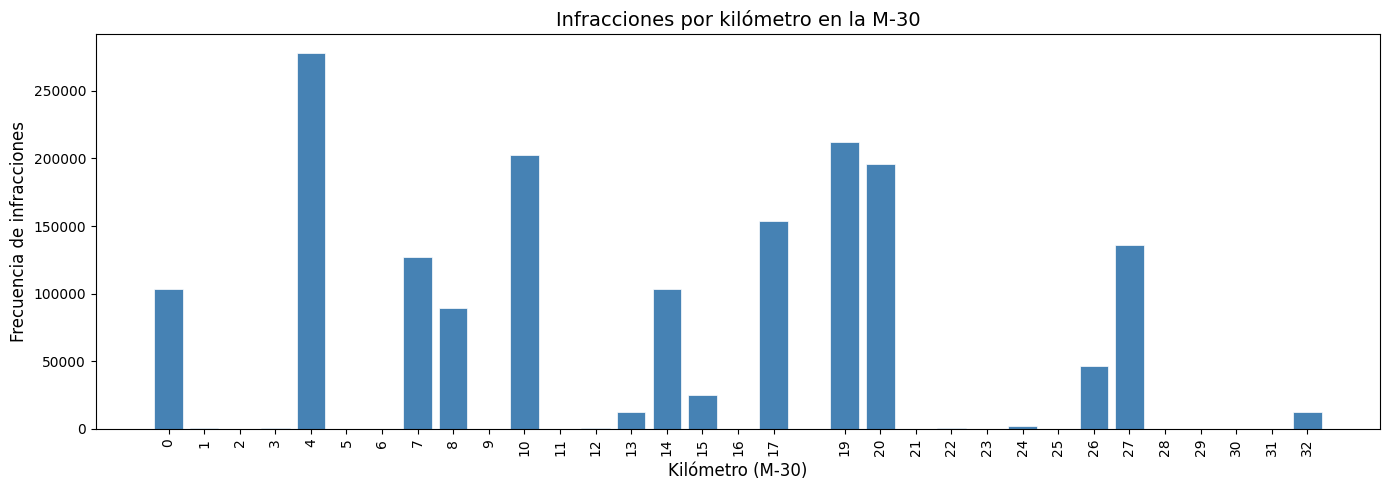

In [ ]:
# ============================================================
# GRÁFICO 1: INFRACCIONES POR KILÓMETRO
# ============================================================

frecuencia_km = (
    m30_multas['KM_round']
    .dropna()
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    frecuencia_km.index,
    frecuencia_km.values,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Kilómetro (M-30)', fontsize=12)
ax.set_ylabel('Frecuencia de infracciones', fontsize=12)
ax.set_title('Infracciones por kilómetro en la M-30', fontsize=14)

ax.set_xticks(frecuencia_km.index)
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
plt.close(fig)

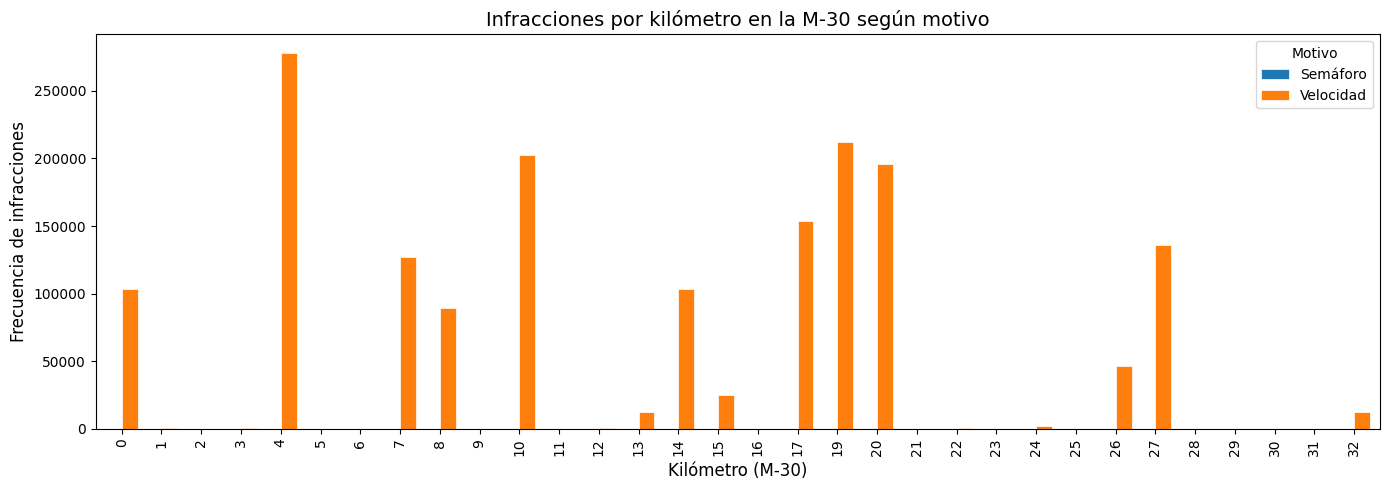

In [ ]:
# ============================================================
# GRÁFICO 2: INFRACCIONES POR KILÓMETRO SEGÚN MOTIVO
# ============================================================

frecuencia_motivo = (
    m30_multas
    .dropna(subset=['KM_round', 'Motivo'])
    .groupby(['KM_round', 'Motivo'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

frecuencia_motivo.plot(
    kind='bar',
    ax=ax,
    edgecolor='white',
    linewidth=0.5,
    width=0.8
)

ax.set_xlabel('Kilómetro (M-30)', fontsize=12)
ax.set_ylabel('Frecuencia de infracciones', fontsize=12)
ax.set_title(
    'Infracciones por kilómetro en la M-30 según motivo',
    fontsize=14
)

ax.legend(title='Motivo', fontsize=10)
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
plt.close(fig)

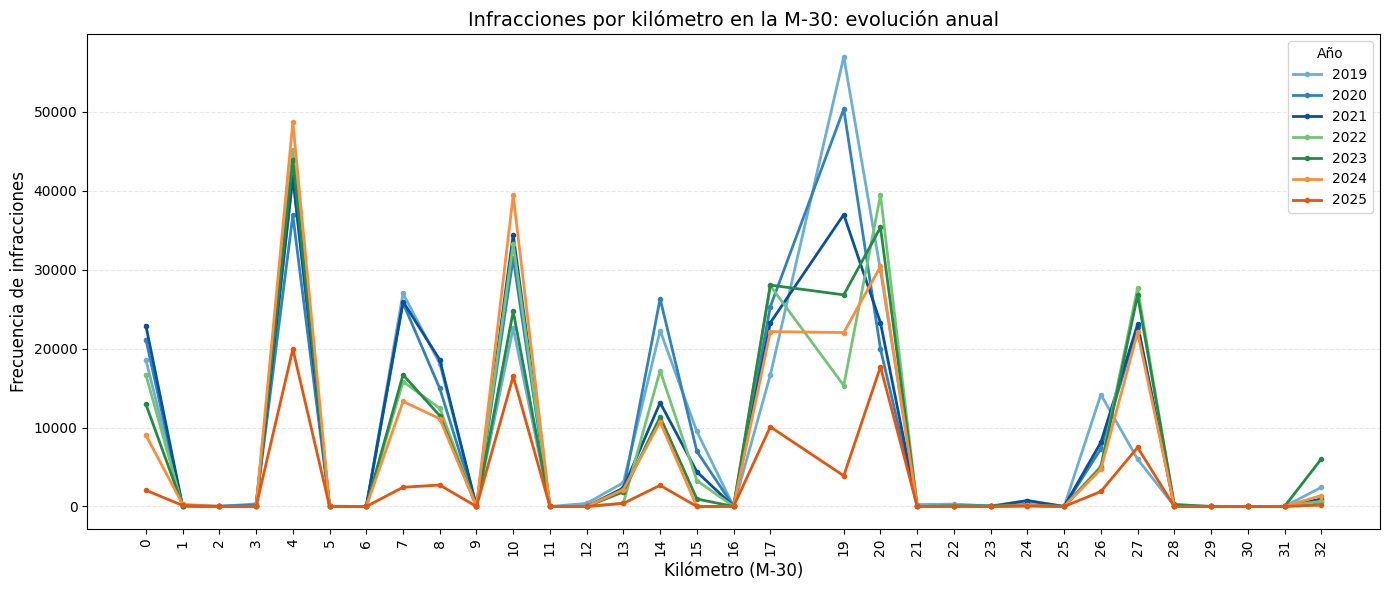

In [ ]:
# ============================================================
# GRÁFICO 3: EVOLUCIÓN ANUAL POR KILÓMETRO
# ============================================================

colores_anio = {
    2019: '#6BAED6',
    2020: '#3182BD',
    2021: '#08519C',
    2022: '#74C476',
    2023: '#238B45',
    2024: '#FD8D3C',
    2025: '#E6550D'
}

fig, ax = plt.subplots(figsize=(14, 6))

for anio in anios:

    df_año = m30_multas[
        m30_multas['anio'] == anio
    ]

    frecuencia_año = (
        df_año['KM_round']
        .value_counts()
        .reindex(kms, fill_value=0)
        .sort_index()
    )

    ax.plot(
        frecuencia_año.index,
        frecuencia_año.values,
        color=colores_anio[int(anio)],
        marker='o',
        markersize=3,
        linewidth=2,
        label=str(int(anio))
    )

ax.set_xlabel('Kilómetro (M-30)', fontsize=12)
ax.set_ylabel('Frecuencia de infracciones', fontsize=12)
ax.set_title(
    'Infracciones por kilómetro en la M-30: evolución anual',
    fontsize=14
)

ax.set_xticks(kms)
ax.tick_params(axis='x', rotation=90)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    title='Año',
    ncol=1,
    fontsize=10
)

plt.tight_layout()

fig.savefig(
    f'{BASE_PATH}/comparativa_infracciones_por_km_anio.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

### Frecuencias por Mes y Año

In [ ]:
m30_multas_mes = (
    m30_multas
    .groupby(['anio', 'mes'])
    .size()
    .reset_index(name='Frecuencia')
)

print(m30_multas_mes)

m30_multas_mes.to_parquet(f'{BASE_PATH}/m30_multas_eventos_mes.parquet', index = True)


    anio  mes  Frecuencia
0   2019    1       28390
1   2019    2       26347
2   2019    3       20898
3   2019    4       21633
4   2019    5       21966
5   2019    6       23595
6   2019    7       26519
7   2019    8       30651
8   2019    9       23708
9   2019   10       23590
10  2019   11       19207
11  2019   12       24622
12  2020    1       28764
13  2020    2       29611
14  2020    3       23770
15  2020    4       12299
16  2020    5       21421
17  2020    6       23046
18  2020    7       31980
19  2020    8       33307
20  2020    9       27218
21  2020   10       20347
22  2020   11       18501
23  2020   12       22150
24  2021    1       31766
25  2021    2       22774
26  2021    3       25890
27  2021    4       24255
28  2021    5       22680
29  2021    6       20127
30  2021    7       22159
31  2021    8       25845
32  2021    9       17150
33  2021   10       20249
34  2021   11       18815
35  2021   12       28243
36  2022    1       24937
37  2022    

### Importar datos M30 de Accidentes

In [ ]:
m30_accidentes_mes = pd.read_parquet(f'{BASE_PATH}/m30_accidentes_eventos_mes.parquet')
m30_accidentes_mes.head()

,anio,mes,Frecuencia
0,2019,1,119
1,2019,2,125
2,2019,3,117
3,2019,4,112
4,2019,5,109


### Fusion de datos M30: Multas y Accidentes

In [ ]:
m30_multas_mes = m30_multas_mes.rename(
    columns={'Frecuencia': 'freq_multas'}
)

m30_accidentes_mes = m30_accidentes_mes.rename(
    columns={'Frecuencia': 'freq_accidentes'}
)

In [ ]:
m30_mes = pd.merge(
    m30_multas_mes,
    m30_accidentes_mes,
    on=['anio', 'mes'],
    how='outer'      # conserva todos los meses presentes en cualquiera de los datasets
)

In [ ]:
# Ordenar y reemplazar posibles valores faltantes

m30_mes = (
    m30_mes
    .sort_values(['anio', 'mes'])
    .fillna(0)
)

m30_mes['freq_multas'] = m30_mes['freq_multas'].astype(int)
m30_mes['freq_accidentes'] = m30_mes['freq_accidentes'].astype(int)

m30_mes

m30_mes.to_csv(f'{BASE_PATH}/m30_mes.csv', index = False)


## Calles Urbanas

In [ ]:
urbanas_multas.head()

,calificacion,Lugar_Original,mes,anio,hora,imp_bol,descuento,puntos,denunciante,hecho_bol,vel_limite,vel_circula,coordenada_x,coordenada_y,source_file,Motivo,Grupo_Calles
26584,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,07.00,50.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv,Velocidad,Urbana
26586,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,07.17,100.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv,Velocidad,Urbana
26593,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,07.53,50.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv,Velocidad,Urbana
26594,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,08.08,50.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv,Velocidad,Urbana
26598,GRAVE,TRAMO AV CORDOBA GT CADIZ-F64,1,2019,10.25,100.0,SI,0,AGENTES DE MOVILIDAD,SOBREPASAR LA VELOCIDAD MEDIA EN TRAMO CONTROLADO.,,,NaN,NaN,201901_detalle.csv,Velocidad,Urbana


### Frecuencias por calles originales

In [ ]:
# Crear el conteo y resetear el índice para convertirlo en DataFrame
tabla_frecuencia_urbanas = urbanas_multas['Lugar_Original'].value_counts().reset_index()

# Renombrar las columnas para que queden bonitas
tabla_frecuencia_urbanas.columns = ['Lugar', 'Frecuencia']

# Añadir una columna de Porcentaje (calculado manualmente o con normalize)
# Opción A: Calcular manual (más control sobre decimales)
total_datos = tabla_frecuencia_urbanas['Frecuencia'].sum()
tabla_frecuencia_urbanas['Porcentaje (%)'] = (tabla_frecuencia_urbanas['Frecuencia'] / total_datos) * 100

# Redondear a 2 decimales
tabla_frecuencia_urbanas['Porcentaje (%)'] = tabla_frecuencia_urbanas['Porcentaje (%)'].round(2)

# Guardar frecuencia_urbana como parquet
tabla_frecuencia_urbanas.to_parquet(f'{BASE_PATH}/tabla_frecuencia_urbanas_multas.parquet', index=False)


In [ ]:
tabla_frecuencia_urbanas = pd.read_parquet(f'{BASE_PATH}/tabla_frecuencia_urbanas_multas.parquet')
print(f"Total de filas únicas encontradas: {len(tabla_frecuencia_urbanas)}")
print(f"Total de frecuencias: {sum(tabla_frecuencia_urbanas['Frecuencia'])}")
print("--- MOSTRANDO TABLA COMPLETA ---")
display(tabla_frecuencia_urbanas.head(50))

Total de filas únicas encontradas: 15224
Total de frecuencias: 1434151
--- MOSTRANDO TABLA COMPLETA ---


,Lugar,Frecuencia,Porcentaje (%)
0,P. SM.CABEZA_N115,126693,8.83
1,A5 KM 4.0 SALIDA,111144,7.75
2,TRAMO A5 KMS 4-5.7 SALIDA,108149,7.54
3,TRAMO A5 KMS 5.7-4 ENTRADA,82093,5.72
4,P. CASTELLANA_300,74379,5.19
5,F005 AV PUERTA DE HIERRO,63001,4.39
6,SUBTRRANEO COSTA RICA,55480,3.87
7,ALCALA - SAN ROMUALDO,22219,1.55
8,VIA LUSITANA - PL ELIPTICA,21678,1.51
9,TRAMO AV CORDOBA GT CADIZ-F64,20515,1.43


### Normalizacion y geolocalizacion

In [ ]:
# # ─────────────────────────────────────────────────────────────
# # USO 3: Integrado en tu flujo completo de TFM
# # ─────────────────────────────────────────────────────────────
# import requests, time
# from google.colab import userdata

# API_KEY = userdata.get('GOOGLE_MAPS_KEY')

# # Porcentaje relativo minimo
# X = 0.7

# # Supón que tienes tu dataset original con la columna "Lugar"
# # df_original_urb = tabla_frecuencia_urbanas[
# #     tabla_frecuencia_urbanas["Porcentaje (%)"] > X
# # ].copy()

# df_original_urb = tabla_frecuencia_urbanas.head(1000).copy()

# df_original_urb.head()

# print(f"Registros antes de limpieza: {len(df_original_urb)}")

# # ── PASO 1: Normalizar con la función ────────────────────────────────
# df_original_urb["Direccion_Geocoding"] = df_original_urb["Lugar"].apply(
#     normalizar_direccion_madrid
# )

# # # ── PASO 2: Corregir casos problemáticos ─────────────────────────────
# # mask_km_via = df_original_urb['Direccion_Geocoding'].str.contains(
# #     r'^Calle [0-9]', regex=True, na=False
# # )
# # mask_snm = df_original_urb['Direccion_Geocoding'].str.contains(
# #     r'Calle Snm', regex=True, na=False
# # )
# # df_original_urb.loc[mask_km_via, 'Direccion_Geocoding'] = (
# #     df_original_urb.loc[mask_km_via, 'Direccion_Geocoding'].apply(corregir_km_via)
# # )
# # df_original_urb.loc[mask_snm, 'Direccion_Geocoding'] = (
# #     df_original_urb.loc[mask_snm, 'Direccion_Geocoding'].apply(corregir_snm)
# # )

# # # ── PASO 3: Descartar irresolubles ───────────────────────────────────
# # _PATRONES_DESCARTAR = [
# #     r'^Calle M2,',
# #     r'^Calle [FK][0-9]',
# #     r'Calle N#',
# #     r'^Calle Av ',
# # ]
# # mask_descartar = df_original_urb['Direccion_Geocoding'].str.contains(
# #     '|'.join(_PATRONES_DESCARTAR), regex=True, na=False
# # )
# # df_original_urb = df_original_urb[~mask_descartar].copy()
# # print(f"Registros tras limpieza: {len(df_original_urb)}")

# # ── PASO 4: Deduplicar para ahorrar llamadas API ─────────────────────
# df_unique_urb = df_original_urb.drop_duplicates(
#     subset="Direccion_Geocoding"
# ).copy().reset_index(drop=True)

# print(f"Registros totales:   {len(df_original_urb)}")
# print(f"Direcciones únicas:  {len(df_unique_urb)}")
# print(f"Llamadas ahorradas:  {len(df_original_urb) - len(df_unique_urb)}")

# # ── PASO 5: Geocodificar con Google Maps API ──────────────────────────
# def geocode_address(address, api_key):
#     url = "https://maps.googleapis.com/maps/api/geocode/json"
#     params = {"address": address, "key": api_key}
#     try:
#         result = requests.get(url, params=params, timeout=10).json()
#         if result["status"] == "OK":
#             loc = result["results"][0]["geometry"]["location"]
#             return loc["lat"], loc["lng"]
#         return None, None
#     except:
#         return None, None

# latitudes, longitudes = [], []
# for i, addr in enumerate(df_unique_urb["Direccion_Geocoding"]):
#     lat, lng = geocode_address(addr, API_KEY)
#     latitudes.append(lat)
#     longitudes.append(lng)
#     if (i + 1) % 50 == 0:
#         print(f"  Procesadas {i+1}/{len(df_unique_urb)}...")
#     time.sleep(0.05)

# df_unique_urb["latitud"]  = latitudes
# df_unique_urb["longitud"] = longitudes

# # ── PASO 6: Merge para llevar coordenadas al df original ─────────────
# df_final_urb = df_original_urb.merge(
#     df_unique_urb[["Direccion_Geocoding", "latitud", "longitud"]],
#     on="Direccion_Geocoding",
#     how="left"
# )

# print(f"\n✅ Registros finales:        {len(df_final_urb)}")
# print(f"   Con coordenadas:          {df_final_urb['latitud'].notna().sum()}")
# print(f"   Sin coordenadas (NaN):    {df_final_urb['latitud'].isna().sum()}")

# df_final_urb.to_parquet(f'{BASE_PATH}/df_final_urb.parquet', index=True)
# print("✅ Guardado: df_final_urb.parquet")

In [ ]:
df_final_urb = pd.read_parquet(f'{BASE_PATH}/df_final_urb.parquet')
df_final_urb.head(50)

,Lugar,Frecuencia,Porcentaje (%),Direccion_Geocoding,latitud,longitud
0,P. SM.CABEZA_N115,126693,8.83,"Paseo de Santa María de la Cabeza 115, Madrid, España",40.390353,-3.709866
1,A5 KM 4.0 SALIDA,111144,7.75,"Autovía A-5 km 4, Madrid, España",40.392776,-3.773081
2,TRAMO A5 KMS 4-5.7 SALIDA,108149,7.54,"Autovía A-5 km 4.85, Madrid, España",40.392776,-3.773081
3,TRAMO A5 KMS 5.7-4 ENTRADA,82093,5.72,"Autovía A-5 km 4.85, Madrid, España",40.392776,-3.773081
4,P. CASTELLANA_300,74379,5.19,"Paseo de la Castellana 300, Madrid, España",40.480052,-3.684829
5,F005 AV PUERTA DE HIERRO,63001,4.39,"Avenida de la Puerta de Hierro, Madrid, España",40.453428,-3.744759
6,SUBTRRANEO COSTA RICA,55480,3.87,"Calle Costa Rica, Madrid, España",40.458760,-3.669946
7,ALCALA - SAN ROMUALDO,22219,1.55,"Calle Alcalá con Calle San Romualdo, Madrid, España",40.441890,-3.623296
8,VIA LUSITANA - PL ELIPTICA,21678,1.51,"Vía Lusitana con Plaza de la Elíptica, Madrid, España",40.385078,-3.717990
9,TRAMO AV CORDOBA GT CADIZ-F64,20515,1.43,"Avenida de Córdoba con Glorieta de Cádiz, Madrid, España",40.170607,-3.664836


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Mapa de frecuencia de multas por localización
# ─────────────────────────────────────────────────────────────────────

import pandas as pd
import plotly.express as px

# 1. Corrección de los dos outliers de geocoding (mismo criterio que en
#    df_final_urb_corregido), aplicada sobre una copia para no tocar df_final_urb
df_multas_mapa = df_final_urb.copy()

mask_cadiz = df_multas_mapa['Direccion_Geocoding'].str.contains(
    'Glorieta de Cádiz', case=False, na=False
)
df_multas_mapa.loc[mask_cadiz, 'latitud']  = 40.395300
df_multas_mapa.loc[mask_cadiz, 'longitud'] = -3.704300

mask_costa_rica = df_multas_mapa['Direccion_Geocoding'].str.contains(
    'Costa Rica-Paraguay', case=False, na=False
)
df_multas_mapa.loc[mask_costa_rica, 'latitud']  = 40.458800
df_multas_mapa.loc[mask_costa_rica, 'longitud'] = -3.669500

# 2. Agrupación por coordenada única (idéntica lógica a 'agrupado', sin
#    ningún cruce con accidentes)
multas_agrupadas_mapa = (
    df_multas_mapa.groupby(['latitud', 'longitud'], as_index=False)
    .agg(
        Frecuencia=('Frecuencia', 'sum'),
        Direccion_Geocoding=('Direccion_Geocoding', 'first')
    )
)

# 3. Mapa
fig_multas = px.scatter_map(
    multas_agrupadas_mapa,
    lat='latitud',
    lon='longitud',
    size='Frecuencia',
    color_discrete_sequence=['#2166AC'],
    size_max=35,
    opacity=0.75,
    zoom=11.5,
    center={'lat': 40.4168, 'lon': -3.7038},
    map_style='carto-positron',
    title='Frecuencia de Multas por localización (2019-2024)',
    height=700
)
fig_multas.update_layout(margin={'r': 0, 't': 50, 'l': 0, 'b': 0})
# fig_multas.write_image(f'{BASE_PATH}/eda_frecuencia_multas.png', scale=3, width=1400, height=900)
fig_multas.write_html(f'{BASE_PATH}/eda_frecuencia_multas.html')
fig_multas.show()

### Frecuencia por calles geolocalizadas

In [ ]:
tabla_coord_urb = (
    df_final_urb.groupby(["latitud", "longitud"])
      .apply(
          lambda g: pd.Series({
              "Frecuencia": g["Frecuencia"].sum(),
              "Direccion_Geocoding":
                  g.groupby("Direccion_Geocoding")["Frecuencia"]
                   .sum()
                   .idxmax()
          })
      )
      .reset_index()
)

tabla_coord_urb["Porcentaje (%)"] = (
    tabla_coord_urb["Frecuencia"] /
    tabla_coord_urb["Frecuencia"].sum() * 100
).round(2)

tabla_coord_urb = tabla_coord_urb.sort_values(
    "Frecuencia",
    ascending=False
).reset_index(drop=True)

print(tabla_coord_urb)

       latitud   longitud  Frecuencia  \
0    40.392776  -3.773081      301386   
1    40.390353  -3.709866      126693   
2    40.480052  -3.684829       74379   
3    40.471492  -3.708271       73802   
4    40.453428  -3.744759       72453   
5    40.458760  -3.669946       55480   
6    40.353269  -3.693128       31321   
7    40.458247  -3.769330       24578   
8    40.441890  -3.623296       23948   
9    40.385078  -3.717990       23807   
10   40.421270  -3.671177       23513   
11   40.438807  -3.708294       21513   
12   40.170607  -3.664836       20515   
13   40.397242  -3.716796       19161   
14   40.406722  -3.672798       19014   
15   40.420710  -3.668885       18230   
16   40.439103  -3.729415       17662   
17   40.438487  -3.700270       16805   
18   40.439855  -3.710233       16572   
19   40.454535  -3.691063       14703   
20   40.430101  -3.710510       14488   
21   40.439146  -3.673383       14265   
22   40.396388  -3.773961       12156   
23   40.435547  

/tmp/ipykernel_751/360507058.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
# ══════════════════════════════════════════════════════════════════════
# VERIFICACIÓN COMPLETA — dataset sin modificaciones
# ══════════════════════════════════════════════════════════════════════

# ── 1. Filas fuera de Madrid ──────────────────────────────────────────
mask_fuera = (
    (tabla_coord_urb['latitud']  < 40.2) | (tabla_coord_urb['latitud']  > 40.7) |
    (tabla_coord_urb['longitud'] < -4.0) | (tabla_coord_urb['longitud'] > -3.4)
)
print(f"Filas fuera de Madrid: {mask_fuera.sum()}")
print(tabla_coord_urb[mask_fuera][['Direccion_Geocoding', 'latitud', 'longitud', 'Frecuencia']])

# ── 2. Direcciones problemáticas (texto) ─────────────────────────────
patrones = [
    r'^Calle [0-9]',
    r'^Calle M[ ,][0-9]',
    r'^Calle M2,',
    r'^Calle [FK][0-9]',
    r'Calle Snm',
    r'Calle N#',
    r'^Calle Av ',
]
mask_prob = tabla_coord_urb['Direccion_Geocoding'].str.contains(
    '|'.join(patrones), regex=True, na=False
)
print(f"\nDirecciones con texto problemático: {mask_prob.sum()}")
print(tabla_coord_urb[mask_prob][['Direccion_Geocoding', 'latitud', 'longitud', 'Frecuencia']])

# ── 3. Resumen general ────────────────────────────────────────────────
total_freq = tabla_coord_urb['Frecuencia'].sum()
print(f"\nTotal filas:               {len(tabla_coord_urb)}")
print(f"Total multas:              {total_freq:,}")
print(f"Fuera de Madrid:           {mask_fuera.sum()} filas | {tabla_coord_urb[mask_fuera]['Frecuencia'].sum():,} multas | {tabla_coord_urb[mask_fuera]['Frecuencia'].sum()/total_freq*100:.2f}%")
print(f"Texto problemático:        {mask_prob.sum()} filas | {tabla_coord_urb[mask_prob]['Frecuencia'].sum():,} multas | {tabla_coord_urb[mask_prob]['Frecuencia'].sum()/total_freq*100:.2f}%")
print(f"Aptos para cruce:          {(~mask_fuera).sum()} filas | {tabla_coord_urb[~mask_fuera]['Frecuencia'].sum():,} multas | {tabla_coord_urb[~mask_fuera]['Frecuencia'].sum()/total_freq*100:.2f}%")

Filas fuera de Madrid: 2
                                          Direccion_Geocoding    latitud  \
12   Avenida de Córdoba con Glorieta de Cádiz, Madrid, España  40.170607   
226                 Calle Costa Rica-Paraguay, Madrid, España -23.442503   

      longitud  Frecuencia  
12   -3.664836       20515  
226 -58.443832          46  

Direcciones con texto problemático: 38
                                     Direccion_Geocoding    latitud  longitud  \
63               Calle 10,0 Av Andalucia, Madrid, España  40.336221 -3.694494   
72                            Calle K015, Madrid, España  40.424636 -3.706581   
73                  Calle 4,6 Av America, Madrid, España  40.352033 -3.695309   
87         Calle Snm Av Juan A Samaranch, Madrid, España  40.483348 -3.617086   
96                Calle 1,0 Av Andalucia, Madrid, España  40.454106 -3.580855   
103                 Calle 4,0 Av America, Madrid, España  40.437489 -3.676949   
105        Calle 0,9 Tunel Pza.Cast. Sal, Madrid, Es

In [ ]:
tabla_coord_urb.to_parquet(f'{BASE_PATH}/tabla_coord_urb.parquet', index = True)
tabla_coord_urb = pd.read_parquet(f'{BASE_PATH}/tabla_coord_urb.parquet')

### Frecuencias por Mes y Año

In [ ]:
urbanas_multas_mes = (
    urbanas_multas
    .groupby(['anio', 'mes'])
    .size()
    .reset_index(name='Frecuencia')
)

print(urbanas_multas_mes)

urbanas_multas_mes.to_parquet(f'{BASE_PATH}/urbanas_multas_eventos_mes.parquet', index = True)


    anio  mes  Frecuencia
0   2019    1       13447
1   2019    2       12047
2   2019    3       12141
3   2019    4       14247
4   2019    5       16609
5   2019    6       16588
6   2019    7       16344
7   2019    8       16052
8   2019    9       13856
9   2019   10       16816
10  2019   11       16767
11  2019   12       16548
12  2020    1       13945
13  2020    2       13964
14  2020    3        9178
15  2020    4        4206
16  2020    5        8087
17  2020    6        9238
18  2020    7       11194
19  2020    8       12344
20  2020    9       11577
21  2020   10        9901
22  2020   11       14086
23  2020   12       19987
24  2021    1       10984
25  2021    2       18191
26  2021    3       22476
27  2021    4       21411
28  2021    5       17441
29  2021    6       14933
30  2021    7       16650
31  2021    8       12880
32  2021    9       14108
33  2021   10       16381
34  2021   11       16515
35  2021   12       19103
36  2022    1       15151
37  2022    

In [ ]:
urbanas_multas_mes = pd.read_parquet(f'{BASE_PATH}/urbanas_multas_eventos_mes.parquet')
print(urbanas_multas_mes)

    anio  mes  Frecuencia
0   2019    1       13447
1   2019    2       12047
2   2019    3       12141
3   2019    4       14247
4   2019    5       16609
5   2019    6       16588
6   2019    7       16344
7   2019    8       16052
8   2019    9       13856
9   2019   10       16816
10  2019   11       16767
11  2019   12       16548
12  2020    1       13945
13  2020    2       13964
14  2020    3        9178
15  2020    4        4206
16  2020    5        8087
17  2020    6        9238
18  2020    7       11194
19  2020    8       12344
20  2020    9       11577
21  2020   10        9901
22  2020   11       14086
23  2020   12       19987
24  2021    1       10984
25  2021    2       18191
26  2021    3       22476
27  2021    4       21411
28  2021    5       17441
29  2021    6       14933
30  2021    7       16650
31  2021    8       12880
32  2021    9       14108
33  2021   10       16381
34  2021   11       16515
35  2021   12       19103
36  2022    1       15151
37  2022    

### Importar datos Urbanos de Accidentes

In [ ]:
urbanas_accidentes_mes = pd.read_parquet(f'{BASE_PATH}/urbanas_accidentes_eventos_mes.parquet')
print(urbanas_accidentes_mes)

    anio  mes  Frecuencia
0   2019    1        1439
1   2019    2        1410
2   2019    3        1580
3   2019    4        1513
4   2019    5        1583
5   2019    6        1594
6   2019    7        1519
7   2019    8        1005
8   2019    9        1459
9   2019   10        1784
10  2019   11        1678
11  2019   12        1568
12  2020    1        1412
13  2020    2        1430
14  2020    3         694
15  2020    4         222
16  2020    5         608
17  2020    6        1031
18  2020    7        1105
19  2020    8         766
20  2020    9        1068
21  2020   10        1154
22  2020   11        1214
23  2020   12        1261
24  2021    1         768
25  2021    2         937
26  2021    3        1219
27  2021    4        1166
28  2021    5        1352
29  2021    6        1443
30  2021    7        1208
31  2021    8         874
32  2021    9        1345
33  2021   10        1696
34  2021   11        1549
35  2021   12        1425
36  2022    1        1301
37  2022    

### Union entre los datasets para calles urbanas

In [ ]:
tabla_acc_agrup = pd.read_parquet(f'{BASE_PATH}/tabla_agrupada_accidentes_urbanas.parquet')

tabla_coord_urbanas_accidentes = pd.read_parquet(f'{BASE_PATH}/tabla_coord_urbanas_accidentes.parquet')

urbanas_accidentes = pd.read_parquet(f'{BASE_PATH}/urbanas_accidentes_sin_geocodificar.parquet')

## Pipeline final
Método: *leader clustering* (BallTree, ordenado por densidad, asignación greedy)

In [ ]:
import numpy as np
import pandas as pd
import re
import unicodedata
import os

# ─────────────────────────────────────────────────────────────────────
# 1. FUNCIONES AUXILIARES
# ─────────────────────────────────────────────────────────────────────

def distancia_km(lat1, lon1, lat2, lon2):
    """Distancia aproximada en km entre dos puntos (fórmula de Haversine)."""
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat / 2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))


def serie_temporal_accidentes(lat_punto, lon_punto, df_accidentes_orig,
                               nombre_referencia='', radio_km=0.150):
    """Serie mensual de accidentes dentro de un radio (Haversine) alrededor de un punto."""
    dist_acc = distancia_km(lat_punto, lon_punto,
                             df_accidentes_orig['latitud'].values,
                             df_accidentes_orig['longitud'].values)
    acc_punto = df_accidentes_orig[dist_acc <= radio_km].copy()
    acc_punto['fecha'] = pd.to_datetime(acc_punto['fecha'])

    serie = (
        acc_punto
        .groupby([
            acc_punto['fecha'].dt.year.rename('anio'),
            acc_punto['fecha'].dt.month.rename('mes')
        ])
        .size()
        .reset_index(name='freq_accidentes')
        .sort_values(['anio', 'mes'])
        .reset_index(drop=True)
    )
    serie['latitud']  = lat_punto
    serie['longitud'] = lon_punto
    serie['nombre']   = nombre_referencia
    return serie


def serie_temporal_multas_exacta(lat_punto, lon_punto, df_multas_orig,
                                  nombre_referencia='', tolerancia=1e-6,
                                  mes_col='mes', anio_col='anio',
                                  lat_col='latitud', lon_col='longitud'):
    """Serie mensual de multas por coincidencia EXACTA de coordenadas geocodificadas."""
    mask = (
        (df_multas_orig[lat_col] - lat_punto).abs() < tolerancia
    ) & (
        (df_multas_orig[lon_col] - lon_punto).abs() < tolerancia
    )
    multas_punto = df_multas_orig[mask].copy()

    serie = (
        multas_punto
        .groupby([anio_col, mes_col])
        .size()
        .reset_index(name='freq_multas')
        .rename(columns={anio_col: 'anio', mes_col: 'mes'})
        .sort_values(['anio', 'mes'])
        .reset_index(drop=True)
    )
    serie['latitud']  = lat_punto
    serie['longitud'] = lon_punto
    serie['nombre']   = nombre_referencia
    return serie


def limpiar_nombre_archivo(nombre):
    """Convierte un nombre de calle en un nombre de archivo válido."""
    nombre = unicodedata.normalize('NFKD', nombre).encode('ASCII', 'ignore').decode('utf-8')
    nombre = re.sub(r',?\s*Madrid,?\s*España\s*$', '', nombre)
    nombre = re.sub(r'[^\w]+', '_', nombre)
    nombre = re.sub(r'_+', '_', nombre).strip('_')
    return nombre


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 2. CORRECCIÓN DE OUTLIERS DE GEOCODING
# Se aplica de forma centralizada sobre df_final_urb, para que TODAS las
# tablas derivadas (agrupado, tabla_directa, df_multas_con_coords) queden
# consistentes entre sí.
# ─────────────────────────────────────────────────────────────────────

df_final_urb_corregido = df_final_urb.copy()

mask_1 = df_final_urb_corregido['Direccion_Geocoding'].str.contains(
    'Glorieta de Cádiz', case=False, na=False
)
df_final_urb_corregido.loc[mask_1, 'latitud']  = 40.395300
df_final_urb_corregido.loc[mask_1, 'longitud'] = -3.704300
print(f"Filas corregidas (Glorieta de Cádiz): {mask_1.sum()}")

mask_2 = df_final_urb_corregido['Direccion_Geocoding'].str.contains(
    'Costa Rica-Paraguay', case=False, na=False
)
df_final_urb_corregido.loc[mask_2, 'latitud']  = 40.458800
df_final_urb_corregido.loc[mask_2, 'longitud'] = -3.669500
print(f"Filas corregidas (Costa Rica-Paraguay): {mask_2.sum()}")

mask_fuera = (
    (df_final_urb_corregido['latitud']  < 40.2) | (df_final_urb_corregido['latitud']  > 40.7) |
    (df_final_urb_corregido['longitud'] < -4.0) | (df_final_urb_corregido['longitud'] > -3.4)
)
print(f"Filas aún fuera de Madrid: {mask_fuera.sum()}")



Filas corregidas (Glorieta de Cádiz): 1
Filas corregidas (Costa Rica-Paraguay): 1
Filas aún fuera de Madrid: 0


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 3. df_multas_con_coords: dataset original de multas (mes/año) + coordenadas
# ─────────────────────────────────────────────────────────────────────

df_multas_con_coords = urbanas_multas.merge(
    df_final_urb_corregido[['Lugar', 'Direccion_Geocoding', 'latitud', 'longitud']],
    left_on='Lugar_Original', right_on='Lugar',
    how='left'
)

match_rate = df_multas_con_coords['latitud'].notna().mean() * 100
print(f"Filas con coordenadas asignadas: {match_rate:.1f}%")
print(f"Total filas: {len(df_multas_con_coords):,}")



Filas con coordenadas asignadas: 97.5%
Total filas: 1,434,151


In [ ]:
# Rango maestro de meses (cubre todo el periodo disponible en ambas fuentes)
fecha_min = min(
    pd.to_datetime(urbanas_accidentes['fecha']).min(),
    pd.to_datetime(df_multas_con_coords[['anio', 'mes']].assign(day=1)
                    .rename(columns={'anio': 'year', 'mes': 'month'})).min()
)
fecha_max = max(
    pd.to_datetime(urbanas_accidentes['fecha']).max(),
    pd.to_datetime(df_multas_con_coords[['anio', 'mes']].assign(day=1)
                    .rename(columns={'anio': 'year', 'mes': 'month'})).max()
)
rango_meses = pd.date_range(start=fecha_min.replace(day=1), end=fecha_max.replace(day=1), freq='MS')
tabla_meses_completa = pd.DataFrame({'anio': rango_meses.year, 'mes': rango_meses.month})

print(f"\nRango maestro: {rango_meses.min().date()} a {rango_meses.max().date()} "
      f"({len(tabla_meses_completa)} meses)\n")



Rango maestro: 2019-01-01 a 2025-10-01 (82 meses)



In [ ]:
puntos_accidentes_crudos = (
    urbanas_accidentes
    .dropna(subset=['latitud', 'longitud'])
    .groupby(['latitud', 'longitud'])
    .size()
    .reset_index(name='Frecuencia')
)

fig_acc_antes = px.scatter_map(
    puntos_accidentes_crudos,
    lat='latitud',
    lon='longitud',
    size='Frecuencia',
    color_discrete_sequence=['#B2182B'],
    size_max=35,
    opacity=0.6,
    zoom=11.5,
    center={'lat': 40.4168, 'lon': -3.7038},
    map_style='carto-positron',
    title='Frecuencia de Accidentes — ANTES de agrupar por radio (puntos crudos)',
    height=700
)
fig_acc_antes.update_layout(margin={'r': 0, 't': 50, 'l': 0, 'b': 0})
# fig_acc_antes.write_image(f'{BASE_PATH}/eda_accidentes_antes_radio.png', scale=3, width=1400, height=900)
fig_acc_antes.write_html(f'{BASE_PATH}/eda_accidentes_antes_radio.html')
fig_acc_antes.show()
print(f'{len(puntos_accidentes_crudos):,} coordenadas únicas (de {len(urbanas_accidentes):,} accidentes totales)')

108,702 coordenadas únicas (de 111,506 accidentes totales)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# PIPELINE: Agrupación de accidentes por radio (150m, SIN pérdidas ni
#           duplicados) → tabla de frecuencias completa → multas encajadas
# ═══════════════════════════════════════════════════════════════════════

from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd
import time

RADIO_KM = 0.150
RADIO_RAD = RADIO_KM / 6371

# ─────────────────────────────────────────────────────────────────────
# 1. Ordenar accidentes por densidad local (para que los centros se
#    ubiquen en los puntos de mayor concentración, no al azar)
# ─────────────────────────────────────────────────────────────────────

t0 = time.time()

coords_acc = urbanas_accidentes[['latitud', 'longitud']].values
coords_acc_rad = np.radians(coords_acc)
tree_acc = BallTree(coords_acc_rad, metric='haversine')

conteos_vecinos = tree_acc.query_radius(coords_acc_rad, r=RADIO_RAD, count_only=True)

df_orden = urbanas_accidentes[['latitud', 'longitud', 'Lugar_Original']].copy()
df_orden['densidad'] = conteos_vecinos
df_orden = df_orden.sort_values('densidad', ascending=False).reset_index(drop=True)

print(f"Orden por densidad calculado | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────────────
# 2. Clustering "leader": cada accidente se une al centro más cercano
#    si está dentro del radio; si no, se convierte en nuevo centro.
#    GARANTIZA: cada accidente pertenece a exactamente un grupo.
# ─────────────────────────────────────────────────────────────────────

t0 = time.time()

centros_lat = []
centros_lon = []
centros_nombre = []
centros_frecuencia = []

lats = df_orden['latitud'].values
lons = df_orden['longitud'].values
nombres = df_orden['Lugar_Original'].values

for i in range(len(df_orden)):
    lat_i, lon_i = lats[i], lons[i]

    if len(centros_lat) == 0:
        # Primer punto: crea el primer centro
        centros_lat.append(lat_i)
        centros_lon.append(lon_i)
        centros_nombre.append(nombres[i])
        centros_frecuencia.append(1)
        continue

    # Distancia a todos los centros existentes hasta ahora
    dist = distancia_km(
        lat_i, lon_i,
        np.array(centros_lat), np.array(centros_lon)
    )
    idx_min = np.argmin(dist)

    if dist[idx_min] <= RADIO_KM:
        # Se une al centro más cercano existente
        centros_frecuencia[idx_min] += 1
    else:
        # Ningún centro cerca: se convierte en nuevo centro
        centros_lat.append(lat_i)
        centros_lon.append(lon_i)
        centros_nombre.append(nombres[i])
        centros_frecuencia.append(1)

tabla_frecuencia_accidentes_completa = pd.DataFrame({
    'latitud': centros_lat,
    'longitud': centros_lon,
    'Lugar_Original': centros_nombre,
    'num_accidentes': centros_frecuencia
})

print(f"{len(tabla_frecuencia_accidentes_completa)} zonas generadas | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────────────
# 3. Verificación: la suma DEBE coincidir exactamente con el total
# ─────────────────────────────────────────────────────────────────────

suma_asignada = tabla_frecuencia_accidentes_completa['num_accidentes'].sum()
print(f"Suma de num_accidentes: {suma_asignada:,}")
print(f"Total real de accidentes: {len(urbanas_accidentes):,}")
print(f"¿Coincide?: {suma_asignada == len(urbanas_accidentes)}")
assert suma_asignada == len(urbanas_accidentes), "No debería poder fallar: revisar lógica"

# ─────────────────────────────────────────────────────────────────────
# 4. Encajar multas: contar multas dentro de 150m de cada centro
#    (usando BallTree para que sea rápido, en vez de un loop con Haversine manual)
# ─────────────────────────────────────────────────────────────────────

t0 = time.time()

coords_multas_rad = np.radians(df_multas_con_coords[['latitud', 'longitud']].dropna().values)
tree_multas = BallTree(coords_multas_rad, metric='haversine')

coords_centros_rad = np.radians(
    tabla_frecuencia_accidentes_completa[['latitud', 'longitud']].values
)
conteo_multas = tree_multas.query_radius(coords_centros_rad, r=RADIO_RAD, count_only=True)

tabla_frecuencia_accidentes_completa['num_multas'] = conteo_multas
print(f"Multas encajadas | {time.time()-t0:.1f}s")

# ─────────────────────────────────────────────────────────────────────
# 5. Ordenar y guardar
# ─────────────────────────────────────────────────────────────────────

tabla_frecuencia_accidentes_completa = tabla_frecuencia_accidentes_completa.sort_values(
    'num_accidentes', ascending=False
).reset_index(drop=True)

print(tabla_frecuencia_accidentes_completa.head(30).to_string())

tabla_frecuencia_accidentes_completa.to_parquet(
    f'{BASE_PATH}/tabla_frecuencia_accidentes_completa.parquet', index=False
)

Orden por densidad calculado | 4.6s
5263 zonas generadas | 30.5s
Suma de num_accidentes: 111,506
Total real de accidentes: 111,506
¿Coincide?: True
Multas encajadas | 1.6s
      latitud  longitud                                     Lugar_Original  num_accidentes  num_multas
0   40.409109 -3.692352           PLAZA. EMPERADOR CARLOS V / CALL. ATOCHA             529          92
1   40.419629 -3.692708                      PLAZA. CIBELES / PASEO. PRADO             463         554
2   40.407291 -3.689069          PASEO. INFANTA ISABEL / CALL. ALFONSO XII             462          40
3   40.425405 -3.690987                        PLAZA. COLON / CALL. GENOVA             429          28
4   40.437870 -3.690112          CALL. MARIA DE MOLINA / PASEO. CASTELLANA             422           0
5   40.398023 -3.668707                                  AVDA. ALBUFERA, 3             407           0
6   40.459355 -3.690356         PLAZA. CUZCO / CALL. SOR ANGELA DE LA CRUZ             402           0
7   

In [ ]:
def serie_temporal_multas_radio(lat_punto, lon_punto, df_multas_orig,
                                 nombre_referencia='', radio_km=0.150,
                                 lat_col='latitud', lon_col='longitud',
                                 mes_col='mes', anio_col='anio'):
    dist_multas = distancia_km(lat_punto, lon_punto,
                                df_multas_orig[lat_col].values,
                                df_multas_orig[lon_col].values)
    multas_punto = df_multas_orig[dist_multas <= radio_km].copy()

    serie = (
        multas_punto
        .groupby([anio_col, mes_col])
        .size()
        .reset_index(name='freq_multas')
        .rename(columns={anio_col: 'anio', mes_col: 'mes'})
        .sort_values(['anio', 'mes'])
        .reset_index(drop=True)
    )
    serie['latitud']  = lat_punto
    serie['longitud'] = lon_punto
    serie['nombre']   = nombre_referencia
    return serie


indices_seleccionados_acc = [10, 14, 23]  # <- ajustado: top 3 zonas por accidentes (edítalo si quieres otras)
series_finales_accidentes = {}

for idx in indices_seleccionados_acc:
    fila = tabla_frecuencia_accidentes_completa.loc[idx]
    nombre = fila['Lugar_Original']

    serie_acc = serie_temporal_accidentes(
        lat_punto=fila['latitud'], lon_punto=fila['longitud'],
        df_accidentes_orig=urbanas_accidentes,
        nombre_referencia=nombre, radio_km=RADIO_KM
    )

    serie_mul = serie_temporal_multas_radio(
        lat_punto=fila['latitud'], lon_punto=fila['longitud'],
        df_multas_orig=df_multas_con_coords,
        nombre_referencia=nombre, radio_km=RADIO_KM
    )

    serie_unida = (
        tabla_meses_completa
        .merge(serie_acc[['anio', 'mes', 'freq_accidentes']], on=['anio', 'mes'], how='left')
        .merge(serie_mul[['anio', 'mes', 'freq_multas']], on=['anio', 'mes'], how='left')
        .fillna(0)
    )
    serie_unida['freq_accidentes'] = serie_unida['freq_accidentes'].astype(int)
    serie_unida['freq_multas'] = serie_unida['freq_multas'].astype(int)
    serie_unida = serie_unida.sort_values(['anio', 'mes']).reset_index(drop=True)
    serie_unida['fecha_mes'] = pd.to_datetime(
        serie_unida['anio'].astype(str) + '-' + serie_unida['mes'].astype(str) + '-01'
    )

    nombre_archivo = limpiar_nombre_archivo(nombre) + '_por_accidentes_1'
    ruta = f'{BASE_PATH}/{nombre_archivo}.csv'
    serie_unida[['anio', 'mes', 'freq_accidentes', 'freq_multas']].to_csv(ruta, index=False)

    existe = os.path.exists(ruta)
    tamano = os.path.getsize(ruta) if existe else 0

    series_finales_accidentes[idx] = {'nombre': nombre, 'serie': serie_unida}

    print(f"[{idx}] {nombre}")
    print(f"    Guardado: {ruta} | existe: {existe} | {tamano} bytes")
    print(f"    Total accidentes: {serie_unida['freq_accidentes'].sum():,}")
    print(f"    Total multas:     {serie_unida['freq_multas'].sum():,}")
    print()

[10] PLAZA. ELIPTICA / CALL. VIA
    Guardado: /content/drive/MyDrive/TFM/notebooks/PLAZA_ELIPTICA_CALL_VIA_por_accidentes_1.csv | existe: True | 1089 bytes
    Total accidentes: 362
    Total multas:     23,837

[14] GTA. MARQUES DE VADILLO, 1
    Guardado: /content/drive/MyDrive/TFM/notebooks/GTA_MARQUES_DE_VADILLO_1_por_accidentes_1.csv | existe: True | 1088 bytes
    Total accidentes: 287
    Total multas:     19,161

[23] CALL. FRANCISCO SILVELA / CALL. DIEGO DE LEON
    Guardado: /content/drive/MyDrive/TFM/notebooks/CALL_FRANCISCO_SILVELA_CALL_DIEGO_DE_LEON_por_accidentes_1.csv | existe: True | 1091 bytes
    Total accidentes: 248
    Total multas:     11,831



In [ ]:
fig_acc_despues = px.scatter_map(
    tabla_frecuencia_accidentes_completa,
    lat='latitud',
    lon='longitud',
    size='num_accidentes',
    color_discrete_sequence=['#B2182B'],
    size_max=35,
    opacity=0.75,
    zoom=11.5,
    center={'lat': 40.4168, 'lon': -3.7038},
    map_style='carto-positron',
    title='Frecuencia de Accidentes — DESPUÉS de agrupar por radio (150m)',
    height=700
)
fig_acc_despues.update_layout(margin={'r': 0, 't': 50, 'l': 0, 'b': 0})
# fig_acc_despues.write_image(f'{BASE_PATH}/eda_accidentes_despues_radio.png', scale=3, width=1400, height=900)
fig_acc_despues.write_html(f'{BASE_PATH}/eda_accidentes_despues_radio.html')
fig_acc_despues.show()
print(f'{len(tabla_frecuencia_accidentes_completa):,} zonas (de {len(urbanas_accidentes):,} accidentes totales)')

5,263 zonas (de 111,506 accidentes totales)
